# Expressivity of DQC1

In [36]:
### environment ###
# macos 13.4  
# matplolib 3.8.4  
# numpy 1.26.4  
# PennyLane 0.35.1

### code reference ###
# https://pennylane.ai/qml/demos/tutorial_expressivity_fourier_series/

# Machine Learning Examples

This demonstration shows that a parameterized DQC1 circuit can be a ML model and its practical expressive power corresponds to our theoretical analysis results.

- Our model :  
$\mathrm{Re}(f(x,\theta))=\mathrm{Re}(\mathrm{tr}(U(x,\theta)/2^n))$
- Target functions : the real parts of  
$g_1(x)=\sum^2_{-2}c_k\exp(ikx)$,  
$g_2(x)=\sum^3_{-3}c_k\exp(ikx)$,  
$g_3(x)=\sum^4_{-4}c_k\exp(ikx)$   ($c_0=0.1, c_k=0.05+0.05i \,(k\neq0)$)

- Theoretical expressivity :  
under the certain assumption described in Sec.$V$ of the paper.  
($n$: the number of qubits, $L$: the number of encoding layers)  
$$
|\Omega|=nL+1
$$  


## Basic Setup

In [155]:
### import packages ###

%matplotlib inline
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as np

### loss function ###

def square_loss(targets, predictions):
    loss = 0
    for t, p in zip(targets, predictions):
        loss += (t - p) ** 2
    loss = loss / len(targets)
    return 0.5*loss

### ansatz 1 unit ###

from pennylane.templates import StronglyEntanglingLayers

n_ansatz_layers = 2
n_qubits = 2

dev = qml.device('default.qubit', wires=n_qubits)
@qml.qnode(dev)
def ansatz_1(weights):
    StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.Identity(wires=0))

weights_ansatz_1 = 2 * np.pi * np.random.random(size=(n_ansatz_layers, n_qubits, 3))
print('ansatz 1 sample')
print(qml.draw(ansatz_1, expansion_strategy="device")(weights_ansatz_1))

### ansatz 2 unit ###

def qcnn_unit9(weights,wire1,wire2):
    qml.U3(weights[0],weights[1],weights[2],wires=wire1)
    qml.U3(weights[3],weights[4],weights[5],wires=wire2)
    qml.CNOT([wire1,wire2])
    qml.RY(weights[6],wire1)
    qml.RZ(weights[7],wire2)
    qml.CNOT([wire2,wire1])
    qml.RY(weights[8],wire1)
    qml.CNOT([wire1,wire2])
    qml.U3(weights[9],weights[10],weights[11],wires=wire1)
    qml.U3(weights[12],weights[13],weights[14],wires=wire2)

dev = qml.device('default.qubit', wires=n_qubits)
@qml.qnode(dev)
def ansatz_2(weights):
    qcnn_unit9(weights[0],0,1)
    return qml.expval(qml.Identity(wires=0))

weights_ansatz_2 = 2 * np.pi * np.random.random(size=(1, 15))
print('ansatz 2 sample')
print(qml.draw(ansatz_2)(weights_ansatz_2))

ansatz 1 sample
0: ──Rot(1.56,3.07,1.72)─╭●─╭X──Rot(0.62,1.89,0.68)─╭●─╭X─┤  <I>
1: ──Rot(1.41,2.17,5.59)─╰X─╰●──Rot(4.01,0.68,4.81)─╰X─╰●─┤     
ansatz 2 sample
0: ──U3(1.34,4.09,1.39)─╭●──RY(1.11)─╭X──RY(2.00)─╭●──U3(3.27,3.16,4.70)─┤  <I>
1: ──U3(0.89,0.02,2.91)─╰X──RZ(0.06)─╰●───────────╰X──U3(6.07,6.20,0.79)─┤     


# $g_1(x)=\sum^2_{-2}c_k\exp(ikx)$ (5 modes) 

## target function

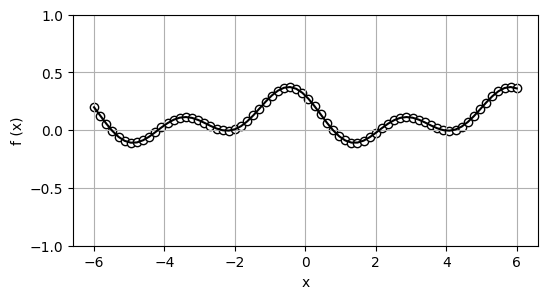

In [42]:
### target function ###

degree = 2  # degree of the target function
scaling = 1  # scaling of the data
coeffs = [0.05 + 0.05j]*degree  # coefficients of non-zero frequencies
coeff0 = 0.1  # coefficient of zero frequency

def target_function(x):
    """Generate a truncated Fourier series, where the data gets re-scaled."""
    res = coeff0
    for idx, coeff in enumerate(coeffs):
        exponent = np.complex128(scaling * (idx+1) * x * 1j)
        conj_coeff = np.conjugate(coeff)
        res += coeff * np.exp(exponent) + conj_coeff * np.exp(-exponent)
    return np.real(res)

x = np.linspace(-6, 6, 70, requires_grad=False)
target_y = np.array([target_function(x_) for x_ in x], requires_grad=True)

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.ylim(-1, 1)
plt.grid()
plt.show();

## model 1 (2-qubit & 2-layer)
$$
|\Omega_{\text{target function}}|=5=|\Omega_{\text{model 1}}|
$$

### Ansatz 1

In [70]:
### setting ansatz ###

ansatz = 1
n_qubits = 2
n_layers = 2
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_1(theta):
    """Trainable circuit block."""
    StronglyEntanglingLayers(theta, wires=range(n_qubits))

@qml.qnode(dev)
def quantum_model_1(weights, x):

    for i in range(n_layers):
        W_1(weights[i])
        S(x)
    W_1(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [44]:
### show ansatz circuit ###

trainable_block_layers = 3
weights = 2 * np.pi * np.random.random(size=(n_layers+1, trainable_block_layers, n_qubits, 3), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_1, expansion_strategy="device")(weights,x_sample))

0: ──Rot(0.85,1.36,3.93)─╭●─╭X──Rot(3.46,2.19,5.77)─╭●─╭X──Rot(6.13,5.52,3.87)─╭●─╭X──RX(-6.00)
1: ──Rot(4.24,3.81,1.32)─╰X─╰●──Rot(4.50,5.79,2.98)─╰X─╰●──Rot(3.69,3.89,2.58)─╰X─╰●──RX(-6.00)

───Rot(5.82,3.50,0.16)─╭●─╭X──Rot(0.13,0.64,5.58)─╭●─╭X──Rot(3.52,2.19,5.73)─╭●─╭X──RX(-6.00)
───Rot(1.06,0.61,3.80)─╰X─╰●──Rot(0.76,5.67,1.81)─╰X─╰●──Rot(6.08,2.61,4.70)─╰X─╰●──RX(-6.00)

───Rot(2.60,5.80,3.68)─╭●─╭X──Rot(5.69,2.72,2.28)─╭●─╭X──Rot(4.71,1.58,5.37)─╭●─╭X─┤  <Z>
───Rot(1.26,0.16,4.46)─╰X─╰●──Rot(3.37,2.93,1.29)─╰X─╰●──Rot(3.37,4.26,5.63)─╰X─╰●─┤     


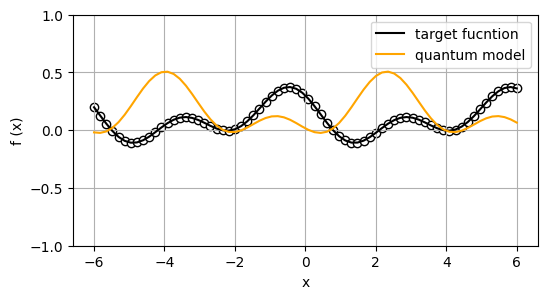

In [45]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [46]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_1)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.010406609486088588
Cost at step  10: 0.008352912909304164
Cost at step  15: 0.0033734592556028467
Cost at step  20: 0.0006282285577991697
Cost at step  25: 0.00034903578837631836
Cost at step  30: 0.00019128315509554908
Cost at step  35: 0.0003218025681046155
Cost at step  40: 8.523278978823519e-05
Cost at step  45: 1.2801111763630053e-05
Cost at step  50: 3.608451155380163e-05
Cost at step  55: 2.365797814715287e-05
Cost at step  60: 3.701178009777124e-05
Cost at step  65: 2.0138051822867523e-05
Cost at step  70: 1.0193095992429448e-05
Cost at step  75: 9.833337403478789e-06
Cost at step  80: 7.670933551606529e-06
Cost at step  85: 2.4368701906721283e-06
Cost at step  90: 2.4483979522743793e-06
Cost at step  95: 1.581286128337989e-06
Cost at step 100: 6.103239145419532e-07
Cost at step 105: 1.570626382068639e-06
Cost at step 110: 7.429241975554424e-07
Cost at step 115: 2.8573720569944496e-07
Cost at step 120: 1.5766033943346338e-06
Cost at step 125: 1.3166627218529

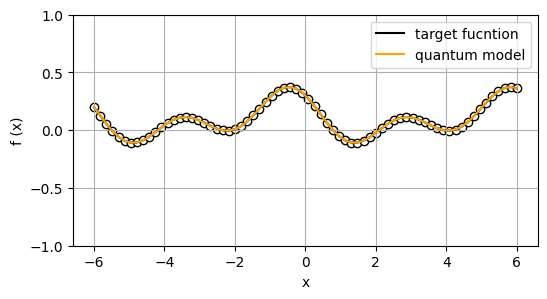

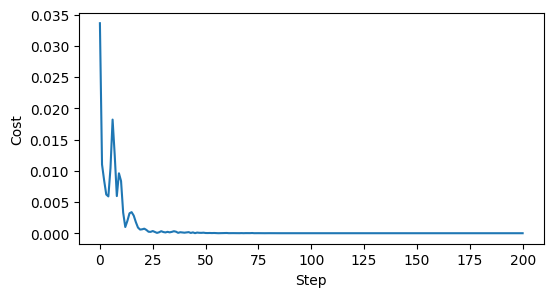

In [50]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [51]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Ansatz 2

In [144]:
### setting ansatz ###

ansatz = 2
n_qubits = 2
n_layers = 2
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_2(theta):
    """Trainable circuit block."""
    qcnn_unit9(theta[0],0,1)

@qml.qnode(dev)
def quantum_model_2(weights, x):

    for i in range(n_layers):
        W_2(weights[i])
        S(x)
    W_2(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [145]:
### show ansatz circuit ###

weights = 2 * np.pi * np.random.random(size=(n_layers+1, 1, 15), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_2, expansion_strategy="device")(weights,x_sample))

0: ──U3(4.04,3.48,6.24)─╭●──RY(4.09)─╭X──RY(0.95)─╭●──U3(3.93,2.51,5.56)──RX(-6.00)
1: ──U3(4.61,2.74,3.30)─╰X──RZ(0.52)─╰●───────────╰X──U3(1.72,2.30,0.93)──RX(-6.00)

───U3(3.52,0.49,3.79)─╭●──RY(4.67)─╭X──RY(1.70)─╭●──U3(0.88,5.59,4.77)──RX(-6.00)
───U3(3.41,1.92,4.18)─╰X──RZ(2.07)─╰●───────────╰X──U3(1.15,2.34,4.19)──RX(-6.00)

───U3(1.96,3.63,2.27)─╭●──RY(3.58)─╭X──RY(1.69)─╭●──U3(1.23,0.49,6.27)─┤  <Z>
───U3(3.41,0.63,2.80)─╰X──RZ(2.22)─╰●───────────╰X──U3(2.86,3.49,2.96)─┤     


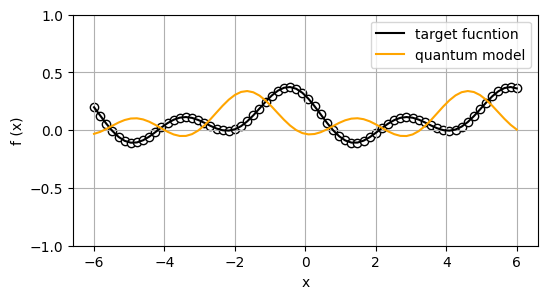

In [146]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [147]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_2)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

/opt/homebrew/Caskroom/miniforge/base/envs/newdqc/lib/python3.9/site-packages/autograd/numpy/numpy_vjps.py:698: ComplexWarning: Casting complex values to real discards the imaginary part
  onp.add.at(A, idx, x)


Cost at step   5: 0.009504671068356497
Cost at step  10: 0.001926411700172275
Cost at step  15: 0.004278518177059813
Cost at step  20: 0.0018510906728622044
Cost at step  25: 0.0009662172078876724
Cost at step  30: 0.0005075143153785727
Cost at step  35: 0.00013543555422318603
Cost at step  40: 0.00020746757172611428
Cost at step  45: 9.606418120165627e-05
Cost at step  50: 5.476292883557525e-05
Cost at step  55: 2.982106535649047e-05
Cost at step  60: 3.0202605867727912e-05
Cost at step  65: 2.5164461071514097e-05
Cost at step  70: 5.255974506060304e-06
Cost at step  75: 5.9378737989053905e-06
Cost at step  80: 1.8329231616133847e-06
Cost at step  85: 2.154550515181166e-06
Cost at step  90: 7.676391668180517e-07
Cost at step  95: 5.097773725563946e-07
Cost at step 100: 2.645465663145574e-07
Cost at step 105: 2.440176367154156e-07
Cost at step 110: 1.0916745131476956e-07
Cost at step 115: 1.597817780014447e-07
Cost at step 120: 1.1156171394673133e-07
Cost at step 125: 4.260000135102865

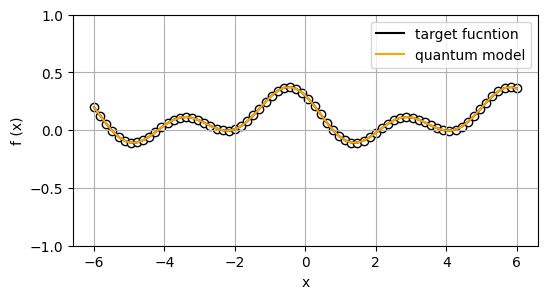

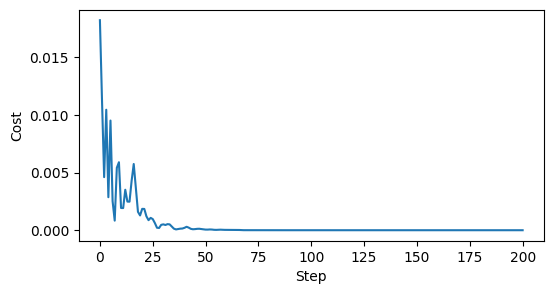

In [148]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [149]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Final Plot

In [75]:
### load weights ###

weights1=np.load('./save/weight_hist_ansatz_1_degree_2_qubits_2_layers_2.npy')[-1]
weights2=np.load('./save/weight_hist_ansatz_2_degree_2_qubits_2_layers_2.npy')[-1]

predictions1 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights1,x_)))) for x_ in x]
predictions2 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights2,x_)))) for x_ in x]

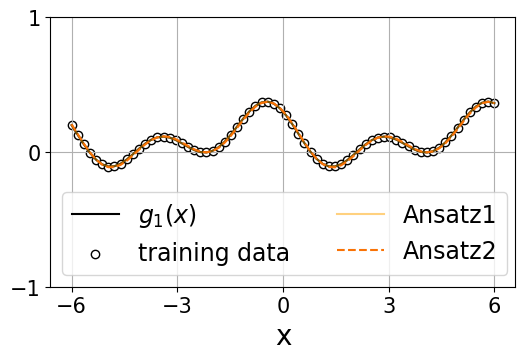

In [76]:
### final plot ###

plt.figure(figsize=(6,3.5))
plt.xlabel('x',fontsize=20)
plt.yticks([-1,0,1],fontsize=15)
plt.xticks([-6,-3,0,3,6],fontsize=15)
plt.plot(x, target_y, c='black',label=r'$g_1(x)$')
plt.scatter(x, target_y, facecolor='white', edgecolor='black',label='training data')
plt.plot(x, predictions1, c='#ffa500',label='Ansatz1',alpha=0.5)
plt.plot(x, predictions2, c='#f97306',label='Ansatz2',linestyle='--')
plt.ylim(-1,1)
plt.grid()
plt.legend(fontsize=17,ncols=2)
plt.show();

## model 2 (3-qubit & 2-layer)
$$
|\Omega_{\text{target function}}|=5<|\Omega_{\text{model 2}}|=7
$$

### Ansatz 1

In [77]:
### setting ansatz ###

ansatz = 1
n_qubits = 3
n_layers = 2
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_1(theta):
    """Trainable circuit block."""
    StronglyEntanglingLayers(theta, wires=range(n_qubits))

@qml.qnode(dev)
def quantum_model_1(weights, x):

    for i in range(n_layers):
        W_1(weights[i])
        S(x)
    W_1(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [78]:
### show ansatz circuit ###

trainable_block_layers = 3
weights = 2 * np.pi * np.random.random(size=(n_layers+1, trainable_block_layers, n_qubits, 3), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_1, expansion_strategy="device")(weights,x_sample))

0: ──Rot(5.41,1.96,5.51)─╭●────╭X──Rot(4.69,0.38,0.84)─╭●─╭X──Rot(5.13,3.90,1.28)
1: ──Rot(5.23,4.77,5.92)─╰X─╭●─│───Rot(2.82,4.03,1.70)─│──╰●─╭X──────────────────
2: ──Rot(4.43,1.67,4.23)────╰X─╰●──Rot(2.55,4.33,3.80)─╰X────╰●──────────────────

───────────────────────╭●────╭X──RX(-6.00)──Rot(1.32,0.56,0.80)─╭●────╭X──Rot(3.95,0.51,3.41)─╭●─╭X
───Rot(3.11,5.95,3.11)─╰X─╭●─│───RX(-6.00)──Rot(2.74,0.66,0.49)─╰X─╭●─│───Rot(0.16,5.29,0.97)─│──╰●
───Rot(3.55,2.29,4.47)────╰X─╰●──RX(-6.00)──Rot(1.66,4.37,5.15)────╰X─╰●──Rot(3.45,5.09,1.84)─╰X───

───Rot(3.28,3.02,5.98)──────────────────────╭●────╭X──RX(-6.00)──Rot(1.52,2.74,4.98)─╭●────╭X
──╭X────────────────────Rot(1.69,1.55,2.64)─╰X─╭●─│───RX(-6.00)──Rot(5.83,1.13,6.24)─╰X─╭●─│─
──╰●────────────────────Rot(4.39,1.67,4.02)────╰X─╰●──RX(-6.00)──Rot(0.36,5.17,1.82)────╰X─╰●

───Rot(5.94,5.54,1.24)─╭●─╭X──Rot(3.28,6.16,2.21)──────────────────────╭●────╭X─┤  <Z>
───Rot(3.47,1.36,4.45)─│──╰●─╭X────────────────────Rot(0.73,5.13,0.84)─╰X─╭●─│──┤ 

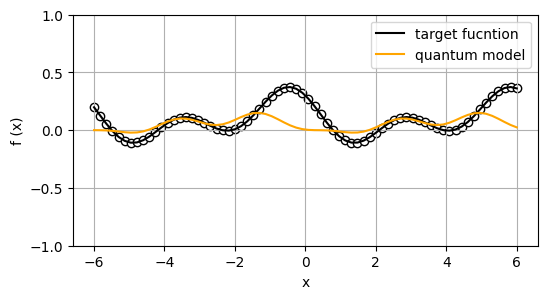

In [79]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [80]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_1)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.0009037986616544101
Cost at step  10: 0.00022485459814761366
Cost at step  15: 0.00020916604656988418
Cost at step  20: 0.00018722808455552814
Cost at step  25: 0.00011753604751783528
Cost at step  30: 2.2604309711787638e-05
Cost at step  35: 1.9323111912372803e-05
Cost at step  40: 0.00010275119834477959
Cost at step  45: 1.2585837485125197e-05
Cost at step  50: 4.607381833326431e-05
Cost at step  55: 2.6900035117711263e-05
Cost at step  60: 8.293211872325399e-06
Cost at step  65: 2.3729128591083778e-05
Cost at step  70: 1.7852618223420432e-05
Cost at step  75: 2.9374235057474855e-05
Cost at step  80: 2.931016810548819e-05
Cost at step  85: 1.2461458860718178e-05
Cost at step  90: 6.074254098426067e-06
Cost at step  95: 9.685852075238986e-06
Cost at step 100: 2.8306815594325735e-05
Cost at step 105: 4.911775303549412e-05
Cost at step 110: 5.060642582278223e-05
Cost at step 115: 6.730027012121738e-05
Cost at step 120: 6.645632664571964e-05
Cost at step 125: 5.748153

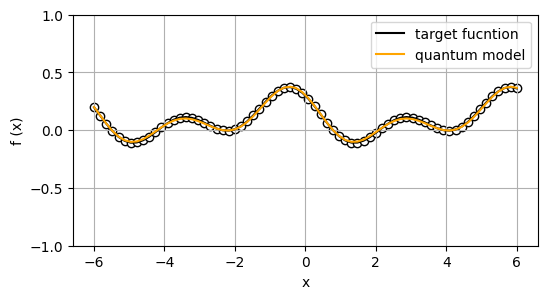

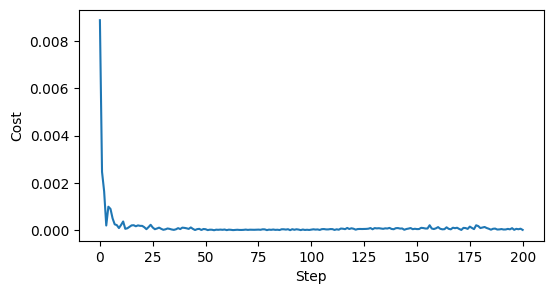

In [81]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [82]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Ansatz 2

In [83]:
### setting ansatz ###

ansatz = 2
n_qubits = 3
n_layers = 2
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_2(theta):
    """Trainable circuit block."""
    qcnn_unit9(theta[0],0,1)
    qcnn_unit9(theta[1],1,2)
    
@qml.qnode(dev)
def quantum_model_2(weights, x):

    for i in range(n_layers):
        W_2(weights[i])
        S(x)
    W_2(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [85]:
### show ansatz circuit ###

weights = 2 * np.pi * np.random.random(size=(n_layers+1, 2,15), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_2, expansion_strategy="device")(weights,x_sample))

0: ──U3(6.22,1.45,5.05)─╭●──RY(1.66)─╭X──RY(1.08)─╭●──U3(5.92,0.49,3.46)──RX(-6.00)─────────
1: ──U3(2.53,0.71,3.74)─╰X──RZ(3.77)─╰●───────────╰X──U3(0.67,2.12,4.98)──U3(2.42,2.56,3.68)
2: ──U3(1.78,5.43,2.37)─────────────────────────────────────────────────────────────────────

───U3(3.73,6.11,3.46)─────────────────────────────────────────────────────────────────────────────
──╭●───────────────────RY(1.46)─╭X──RY(0.43)─╭●──U3(0.97,5.87,4.23)──RX(-6.00)──U3(0.82,1.49,5.13)
──╰X───────────────────RZ(3.38)─╰●───────────╰X──U3(0.38,1.46,1.68)──RX(-6.00)──U3(5.81,5.51,3.88)

──╭●──RY(2.17)─╭X──RY(3.90)─╭●──U3(4.41,6.08,6.24)──RX(-6.00)───────────U3(4.20,5.23,1.30)──────────
──╰X──RZ(4.34)─╰●───────────╰X──U3(5.96,4.56,5.48)──U3(5.00,1.77,2.54)─╭●───────────────────RY(3.15)
───────────────────────────────────────────────────────────────────────╰X───────────────────RZ(6.23)

─────────────────────────────────────────────────────────────────────╭●──RY(4.65)─╭X──RY(5.51)─╭●
──╭X──RY(0.81)─╭●──U

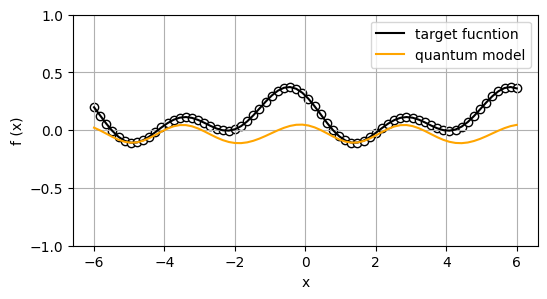

In [86]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [87]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_2)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

/opt/homebrew/Caskroom/miniforge/base/envs/newdqc/lib/python3.9/site-packages/autograd/numpy/numpy_vjps.py:698: ComplexWarning: Casting complex values to real discards the imaginary part
  onp.add.at(A, idx, x)


Cost at step   5: 0.00585414039393321
Cost at step  10: 0.005712807984062561
Cost at step  15: 0.001756936177387076
Cost at step  20: 0.0007818020624389854
Cost at step  25: 0.00037768028564739336
Cost at step  30: 0.00015812814299429962
Cost at step  35: 0.00016782576122227003
Cost at step  40: 0.00011244703813795058
Cost at step  45: 3.76238409660699e-05
Cost at step  50: 4.663178409546952e-05
Cost at step  55: 4.712769955667974e-05
Cost at step  60: 8.165521279040702e-06
Cost at step  65: 2.1776610841068478e-05
Cost at step  70: 8.767668078613568e-06
Cost at step  75: 4.57441404067185e-06
Cost at step  80: 2.8961382893744495e-06
Cost at step  85: 6.424125815414229e-06
Cost at step  90: 4.829431938452479e-06
Cost at step  95: 6.251375385027549e-07
Cost at step 100: 5.982076199023247e-07
Cost at step 105: 9.913502585225733e-07
Cost at step 110: 1.329507970681794e-07
Cost at step 115: 3.100263536108245e-07
Cost at step 120: 5.704475454262582e-07
Cost at step 125: 3.043311959534817e-07


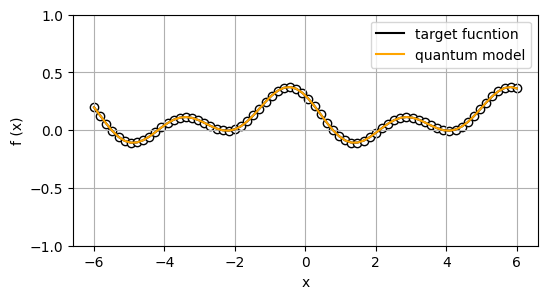

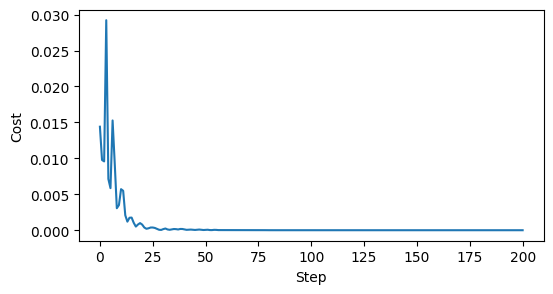

In [88]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [89]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Final Plot

In [90]:
### load weights ###

weights1=np.load('./save/weight_hist_ansatz_1_degree_2_qubits_3_layers_2.npy')[-1]
weights2=np.load('./save/weight_hist_ansatz_2_degree_2_qubits_3_layers_2.npy')[-1]

predictions1 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights1,x_)))) for x_ in x]
predictions2 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights2,x_)))) for x_ in x]

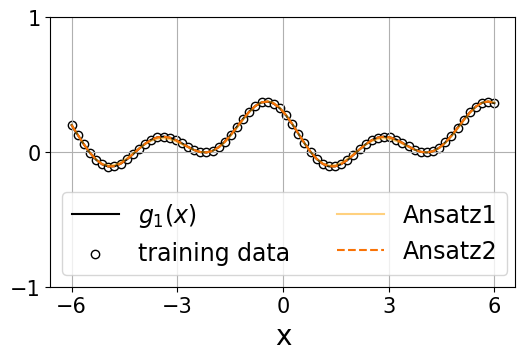

In [91]:
### final plot ###

plt.figure(figsize=(6,3.5))
plt.xlabel('x',fontsize=20)
plt.yticks([-1,0,1],fontsize=15)
plt.xticks([-6,-3,0,3,6],fontsize=15)
plt.plot(x, target_y, c='black',label=r'$g_1(x)$')
plt.scatter(x, target_y, facecolor='white', edgecolor='black',label='training data')
plt.plot(x, predictions1, c='#ffa500',label='Ansatz1',alpha=0.5)
plt.plot(x, predictions2, c='#f97306',label='Ansatz2',linestyle='--')
plt.ylim(-1,1)
plt.grid()
plt.legend(fontsize=17,ncols=2)
plt.show();

## model 3 (2-qubit & 3-layer)
$$
|\Omega_{\text{target function}}|=5<|\Omega_{\text{model 3}}|=7
$$

### Ansatz 1

In [97]:
### setting ansatz ###

ansatz = 1
n_qubits = 2
n_layers = 3
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_1(theta):
    """Trainable circuit block."""
    StronglyEntanglingLayers(theta, wires=range(n_qubits))

@qml.qnode(dev)
def quantum_model_1(weights, x):

    for i in range(n_layers):
        W_1(weights[i])
        S(x)
    W_1(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [98]:
### show ansatz circuit ###

trainable_block_layers = 3
weights = 2 * np.pi * np.random.random(size=(n_layers+1, trainable_block_layers, n_qubits, 3), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_1, expansion_strategy="device")(weights,x_sample))

0: ──Rot(4.89,5.70,3.60)─╭●─╭X──Rot(4.07,6.06,0.46)─╭●─╭X──Rot(1.28,5.33,0.53)─╭●─╭X──RX(-6.00)
1: ──Rot(2.69,5.76,1.73)─╰X─╰●──Rot(3.91,1.81,2.91)─╰X─╰●──Rot(0.43,2.54,3.99)─╰X─╰●──RX(-6.00)

───Rot(5.52,3.28,3.02)─╭●─╭X──Rot(5.37,0.15,0.89)─╭●─╭X──Rot(5.59,4.79,0.79)─╭●─╭X──RX(-6.00)
───Rot(2.33,3.98,4.05)─╰X─╰●──Rot(2.04,3.29,2.59)─╰X─╰●──Rot(5.69,1.58,2.38)─╰X─╰●──RX(-6.00)

───Rot(1.58,2.60,5.09)─╭●─╭X──Rot(5.18,5.17,1.21)─╭●─╭X──Rot(1.78,4.23,2.63)─╭●─╭X──RX(-6.00)
───Rot(3.76,4.11,3.57)─╰X─╰●──Rot(2.80,3.07,1.86)─╰X─╰●──Rot(2.62,4.01,4.14)─╰X─╰●──RX(-6.00)

───Rot(0.14,3.38,2.25)─╭●─╭X──Rot(3.76,4.95,0.85)─╭●─╭X──Rot(3.50,5.04,6.05)─╭●─╭X─┤  <Z>
───Rot(2.32,2.96,0.79)─╰X─╰●──Rot(5.17,3.93,2.70)─╰X─╰●──Rot(3.47,0.89,1.09)─╰X─╰●─┤     


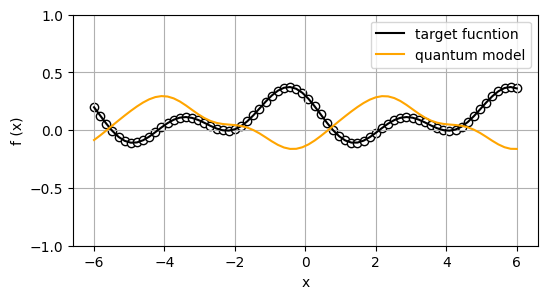

In [100]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [101]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_1)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.0023694541232953223
Cost at step  10: 0.0010626897770159066
Cost at step  15: 0.0005456992529401521
Cost at step  20: 0.0005332862257392608
Cost at step  25: 0.0002371899130918473
Cost at step  30: 0.00017277750278343946
Cost at step  35: 0.00010871455401263133
Cost at step  40: 6.913057901529483e-05
Cost at step  45: 5.4592865236440805e-05
Cost at step  50: 7.235831419706134e-05
Cost at step  55: 2.6812556000072826e-05
Cost at step  60: 5.821524202148287e-05
Cost at step  65: 4.024447250106032e-05
Cost at step  70: 2.4273662581196218e-05
Cost at step  75: 2.410422188006789e-05
Cost at step  80: 5.930905659483028e-06
Cost at step  85: 1.001723792500305e-05
Cost at step  90: 0.0004786398269356371
Cost at step  95: 0.0002714690908803975
Cost at step 100: 0.0006459453399866241
Cost at step 105: 0.0001199283705063284
Cost at step 110: 0.00022398893807718285
Cost at step 115: 0.00018221438788281686
Cost at step 120: 0.0001747331929948081
Cost at step 125: 0.0002770593305

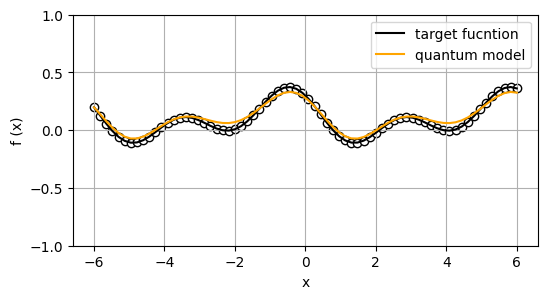

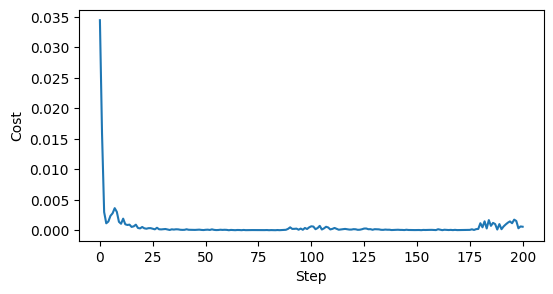

In [102]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [103]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Ansatz 2

In [107]:
### setting ansatz ###

ansatz = 2
n_qubits = 2
n_layers = 3
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_2(theta):
    """Trainable circuit block."""
    qcnn_unit9(theta[0],0,1)
    
@qml.qnode(dev)
def quantum_model_2(weights, x):

    for i in range(n_layers):
        W_2(weights[i])
        S(x)
    W_2(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [109]:
### show ansatz circuit ###

weights = 2 * np.pi * np.random.random(size=(n_layers+1, 1, 15), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_2, expansion_strategy="device")(weights,x_sample))

0: ──U3(0.42,6.16,0.03)─╭●──RY(2.66)─╭X──RY(5.39)─╭●──U3(3.03,2.27,3.43)──RX(-6.00)
1: ──U3(3.59,6.02,0.96)─╰X──RZ(4.98)─╰●───────────╰X──U3(5.08,5.14,6.27)──RX(-6.00)

───U3(5.51,4.70,4.50)─╭●──RY(0.74)─╭X──RY(5.96)─╭●──U3(4.03,0.20,5.08)──RX(-6.00)
───U3(1.02,2.66,1.61)─╰X──RZ(2.90)─╰●───────────╰X──U3(4.12,4.69,0.61)──RX(-6.00)

───U3(0.72,1.72,4.39)─╭●──RY(2.59)─╭X──RY(2.93)─╭●──U3(2.67,2.51,1.46)──RX(-6.00)
───U3(1.61,2.74,0.98)─╰X──RZ(1.92)─╰●───────────╰X──U3(2.83,0.44,1.80)──RX(-6.00)

───U3(4.71,1.83,3.93)─╭●──RY(0.58)─╭X──RY(1.46)─╭●──U3(6.20,0.69,4.85)─┤  <Z>
───U3(2.93,5.56,1.45)─╰X──RZ(3.59)─╰●───────────╰X──U3(1.73,0.70,0.89)─┤     


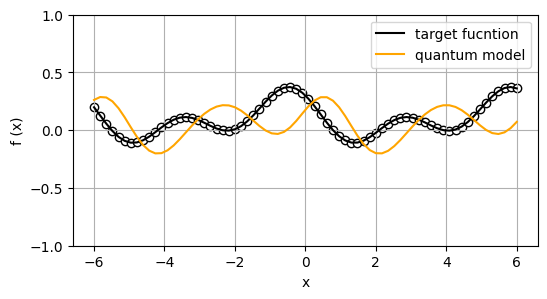

In [110]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [111]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_2)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

/opt/homebrew/Caskroom/miniforge/base/envs/newdqc/lib/python3.9/site-packages/autograd/numpy/numpy_vjps.py:698: ComplexWarning: Casting complex values to real discards the imaginary part
  onp.add.at(A, idx, x)


Cost at step   5: 0.01258902544512423
Cost at step  10: 0.013954412029202418
Cost at step  15: 0.004848401205208428
Cost at step  20: 0.0021766804350493063
Cost at step  25: 0.001281347397374564
Cost at step  30: 0.0010998557678920608
Cost at step  35: 0.00025648918980129116
Cost at step  40: 0.0004099227037210281
Cost at step  45: 0.0003386409136943062
Cost at step  50: 0.00014332189381547621
Cost at step  55: 0.00013262750569691397
Cost at step  60: 2.812683988534454e-05
Cost at step  65: 7.331876276771889e-05
Cost at step  70: 7.096227481468344e-05
Cost at step  75: 4.945338294678972e-05
Cost at step  80: 6.334024725117624e-06
Cost at step  85: 3.953314347250336e-05
Cost at step  90: 4.618290172522344e-05
Cost at step  95: 1.829208862999387e-05
Cost at step 100: 5.18803702788008e-06
Cost at step 105: 4.039797249732755e-06
Cost at step 110: 1.313814030424036e-05
Cost at step 115: 7.886850645470533e-06
Cost at step 120: 2.925337186995094e-06
Cost at step 125: 3.6102459507625806e-06
Co

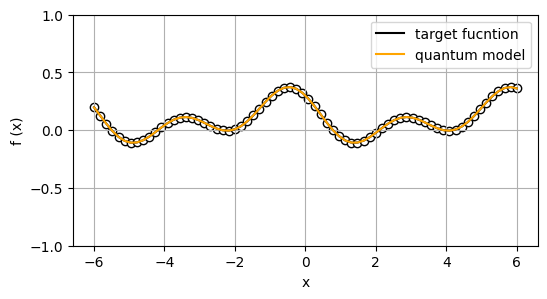

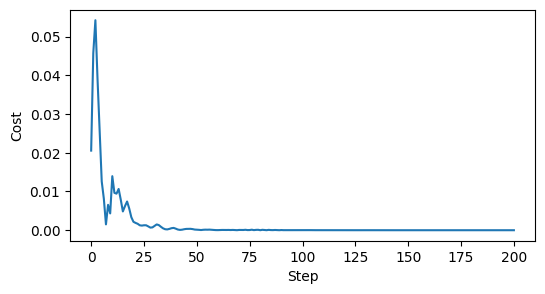

In [112]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [113]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Final Plot

In [114]:
### load weights ###

weights1=np.load('./save/weight_hist_ansatz_1_degree_2_qubits_2_layers_3.npy')[-1]
weights2=np.load('./save/weight_hist_ansatz_2_degree_2_qubits_2_layers_3.npy')[-1]

predictions1 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights1,x_)))) for x_ in x]
predictions2 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights2,x_)))) for x_ in x]

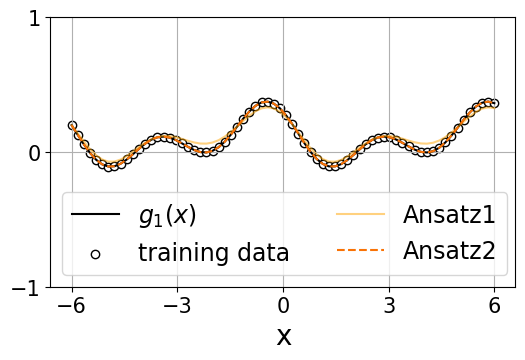

In [115]:
### final plot ###

plt.figure(figsize=(6,3.5))
plt.xlabel('x',fontsize=20)
plt.yticks([-1,0,1],fontsize=15)
plt.xticks([-6,-3,0,3,6],fontsize=15)
plt.plot(x, target_y, c='black',label=r'$g_1(x)$')
plt.scatter(x, target_y, facecolor='white', edgecolor='black',label='training data')
plt.plot(x, predictions1, c='#ffa500',label='Ansatz1',alpha=0.5)
plt.plot(x, predictions2, c='#f97306',label='Ansatz2',linestyle='--')
plt.ylim(-1,1)
plt.grid()
plt.legend(fontsize=17,ncols=2)
plt.show();

## model 4 (4-qubit & 2-layer)
$$
|\Omega_{\text{target function}}|=5<|\Omega_{\text{model 4}}|=9
$$

### Ansatz 1

In [116]:
### setting ansatz ###

ansatz = 1
n_qubits = 4
n_layers = 2
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_1(theta):
    """Trainable circuit block."""
    StronglyEntanglingLayers(theta, wires=range(n_qubits))

@qml.qnode(dev)
def quantum_model_1(weights, x):

    for i in range(n_layers):
        W_1(weights[i])
        S(x)
    W_1(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [117]:
### show ansatz circuit ###

trainable_block_layers = 3
weights = 2 * np.pi * np.random.random(size=(n_layers+1, trainable_block_layers, n_qubits, 3), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_1, expansion_strategy="device")(weights,x_sample))

0: ──Rot(0.90,1.37,2.14)─╭●───────╭X──Rot(4.48,5.64,3.60)─╭●────╭X──Rot(5.84,0.97,1.49)
1: ──Rot(0.11,4.41,3.29)─╰X─╭●────│───Rot(0.04,2.43,1.71)─│──╭●─│──╭X──────────────────
2: ──Rot(5.74,4.79,2.03)────╰X─╭●─│───Rot(0.95,4.36,3.04)─╰X─│──╰●─│───────────────────
3: ──Rot(0.34,1.24,0.16)───────╰X─╰●──Rot(4.77,5.58,4.24)────╰X────╰●──────────────────

───────────────────────╭●─╭X──RX(-6.00)──Rot(4.09,2.91,5.86)─────────────────────
───Rot(1.16,1.33,2.77)─│──╰●─╭X──────────RX(-6.00)────────────Rot(2.49,1.02,1.98)
───Rot(5.86,3.53,0.11)─│─────╰●─────────╭X────────────────────RX(-6.00)──────────
───Rot(2.46,2.33,5.37)─╰X───────────────╰●────────────────────RX(-6.00)──────────

──╭●─────────────────────────╭X──Rot(5.98,5.96,1.09)─╭●────╭X──Rot(0.91,2.35,1.14)
──╰X───────────────────╭●────│───Rot(2.90,6.16,3.66)─│──╭●─│──╭X──────────────────
───Rot(1.85,2.57,1.57)─╰X─╭●─│───Rot(1.47,1.13,3.26)─╰X─│──╰●─│───────────────────
───Rot(5.65,0.40,4.36)────╰X─╰●──Rot(5.45,1.50,5.59)────╰X────╰●─────

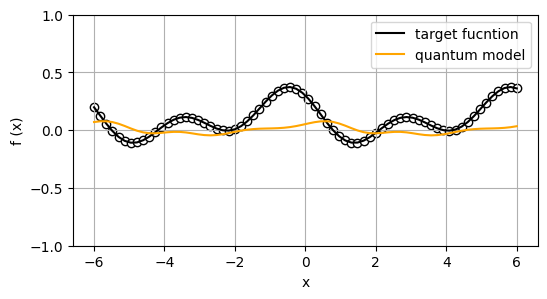

In [118]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [119]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_1)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.0016983967952040487
Cost at step  10: 0.0012847794502656635
Cost at step  15: 0.0004691694190554386
Cost at step  20: 0.0003447385293653895
Cost at step  25: 0.00023299689135235175
Cost at step  30: 9.881255167006048e-05
Cost at step  35: 4.398148331647368e-05
Cost at step  40: 3.0041337392880025e-05
Cost at step  45: 2.9239661500629188e-05
Cost at step  50: 9.776938022471776e-06
Cost at step  55: 1.1049764116533748e-05
Cost at step  60: 1.0641614684873893e-05
Cost at step  65: 6.909845612481017e-06
Cost at step  70: 4.404506713382243e-06
Cost at step  75: 2.804613787828733e-06
Cost at step  80: 3.781408870380001e-06
Cost at step  85: 3.377868945282414e-06
Cost at step  90: 4.114561824657757e-06
Cost at step  95: 2.7417315472577434e-06
Cost at step 100: 4.4992918301113436e-07
Cost at step 105: 1.5716379368956773e-06
Cost at step 110: 8.588922646763118e-07
Cost at step 115: 1.4433549492559066e-06
Cost at step 120: 3.603758732017267e-06
Cost at step 125: 2.36118760839

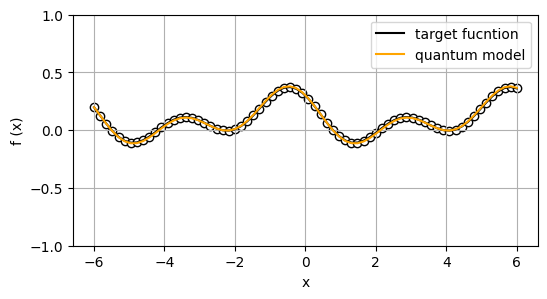

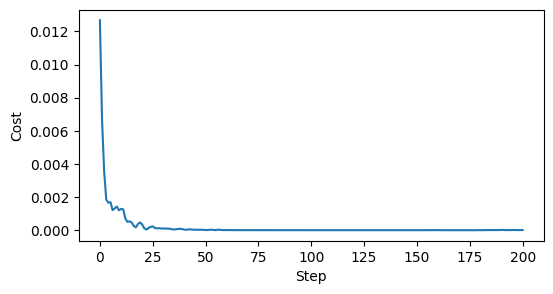

In [120]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [121]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Ansatz 2

In [122]:
### setting ansatz ###

ansatz = 2
n_qubits = 4
n_layers = 2
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_2(theta):
    """Trainable circuit block."""
    qcnn_unit9(theta[0],0,1)
    qcnn_unit9(theta[1],2,3)
    qcnn_unit9(theta[2],1,2)
    qcnn_unit9(theta[3],3,0)
    
@qml.qnode(dev)
def quantum_model_2(weights, x):

    for i in range(n_layers):
        W_2(weights[i])
        S(x)
    W_2(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [123]:
### show ansatz circuit ###

weights = 2 * np.pi * np.random.random(size=(n_layers+1, 4, 15), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_2, expansion_strategy="device")(weights,x_sample))

0: ──U3(4.41,6.13,3.68)─╭●──RY(4.51)─╭X──RY(2.84)─╭●──U3(3.70,3.03,6.21)──U3(0.77,3.84,4.55)───
1: ──U3(4.21,5.92,4.41)─╰X──RZ(6.16)─╰●───────────╰X──U3(1.56,1.36,3.01)──U3(1.95,4.78,5.07)─╭●
2: ──U3(5.57,5.26,0.97)─╭●──RY(2.52)─╭X──RY(2.39)─╭●──U3(6.19,1.40,4.59)──U3(0.56,4.57,4.35)─╰X
3: ──U3(5.38,4.09,5.76)─╰X──RZ(5.98)─╰●───────────╰X──U3(0.34,2.12,5.16)──U3(3.01,5.74,5.51)───

────────────────────────────────────────────────╭X──RZ(2.08)─╭●───────────╭X──U3(0.89,6.13,5.95)
───RY(3.47)─╭X──RY(3.98)─╭●──U3(4.84,0.39,5.22)─│────────────│────────────│───RX(-6.00)─────────
───RZ(0.41)─╰●───────────╰X──U3(4.15,2.50,0.18)─│────────────│────────────│───RX(-6.00)─────────
────────────────────────────────────────────────╰●──RY(1.63)─╰X──RY(3.81)─╰●──U3(5.76,1.24,5.53)

───RX(-6.00)───────────U3(4.26,4.97,6.27)─╭●──RY(5.05)─╭X──RY(5.45)─╭●──U3(3.51,2.25,1.12)
───U3(1.99,2.35,1.72)─────────────────────╰X──RZ(3.65)─╰●───────────╰X──U3(3.13,2.07,2.85)
───U3(4.91,0.83,6.19)─────────────────────╭●

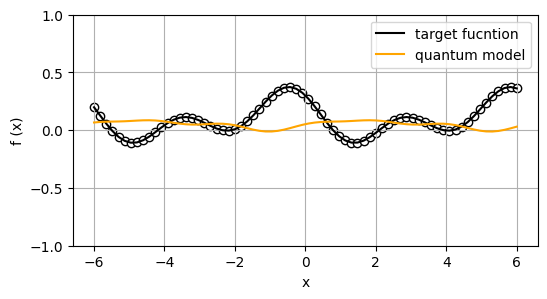

In [124]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [125]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_2)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

/opt/homebrew/Caskroom/miniforge/base/envs/newdqc/lib/python3.9/site-packages/autograd/numpy/numpy_vjps.py:698: ComplexWarning: Casting complex values to real discards the imaginary part
  onp.add.at(A, idx, x)


Cost at step   5: 0.004086872283092203
Cost at step  10: 0.008327154491157753
Cost at step  15: 0.0006669304729324661
Cost at step  20: 0.0006843234749858985
Cost at step  25: 0.0003357336136501555
Cost at step  30: 0.00015597761733832913
Cost at step  35: 0.00012130962048018077
Cost at step  40: 0.00010397213500859061
Cost at step  45: 9.630289700807486e-05
Cost at step  50: 5.490806349067038e-05
Cost at step  55: 2.6777595791187183e-05
Cost at step  60: 1.3649721111198014e-05
Cost at step  65: 2.6607313522319835e-05
Cost at step  70: 2.091237461142067e-05
Cost at step  75: 9.616216207065813e-06
Cost at step  80: 7.994922848742758e-06
Cost at step  85: 6.841428449297562e-06
Cost at step  90: 3.07197634308875e-06
Cost at step  95: 1.3186634511795662e-06
Cost at step 100: 1.0629090762018438e-06
Cost at step 105: 9.740292593118956e-07
Cost at step 110: 1.2912472700329235e-06
Cost at step 115: 3.621741081938058e-07
Cost at step 120: 8.794055611727086e-08
Cost at step 125: 2.87929434352204

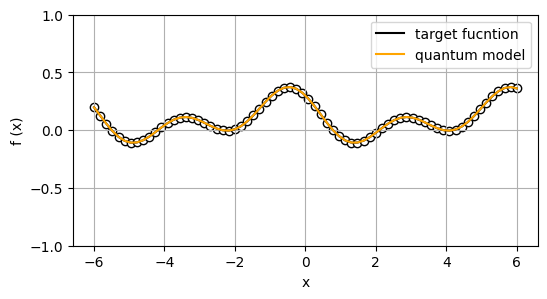

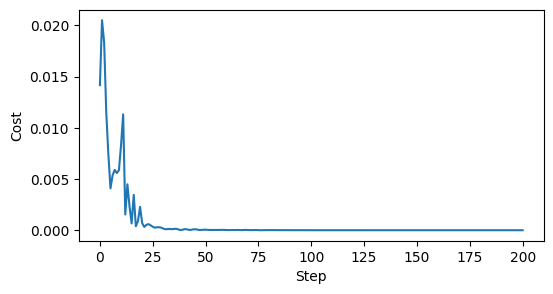

In [126]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [127]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Final Plot

In [128]:
### load weights ###

weights1=np.load('./save/weight_hist_ansatz_1_degree_2_qubits_4_layers_2.npy')[-1]
weights2=np.load('./save/weight_hist_ansatz_2_degree_2_qubits_4_layers_2.npy')[-1]

predictions1 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights1,x_)))) for x_ in x]
predictions2 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights2,x_)))) for x_ in x]

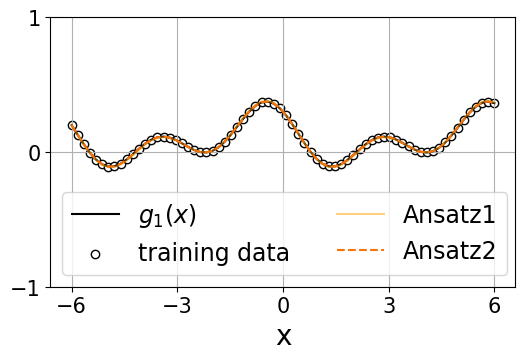

In [129]:
### final plot ###

plt.figure(figsize=(6,3.5))
plt.xlabel('x',fontsize=20)
plt.yticks([-1,0,1],fontsize=15)
plt.xticks([-6,-3,0,3,6],fontsize=15)
plt.plot(x, target_y, c='black',label=r'$g_1(x)$')
plt.scatter(x, target_y, facecolor='white', edgecolor='black',label='training data')
plt.plot(x, predictions1, c='#ffa500',label='Ansatz1',alpha=0.5)
plt.plot(x, predictions2, c='#f97306',label='Ansatz2',linestyle='--')
plt.ylim(-1,1)
plt.grid()
plt.legend(fontsize=17,ncols=2)
plt.show();

## model 5 (2-qubit & 4-layer)
$$
|\Omega_{\text{target function}}|=5<|\Omega_{\text{model 5}}|=9
$$

### Ansatz 1

In [130]:
### setting ansatz ###

ansatz = 1
n_qubits = 2
n_layers = 4
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_1(theta):
    """Trainable circuit block."""
    StronglyEntanglingLayers(theta, wires=range(n_qubits))

@qml.qnode(dev)
def quantum_model_1(weights, x):

    for i in range(n_layers):
        W_1(weights[i])
        S(x)
    W_1(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [131]:
### show ansatz circuit ###

trainable_block_layers = 3
weights = 2 * np.pi * np.random.random(size=(n_layers+1, trainable_block_layers, n_qubits, 3), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_1, expansion_strategy="device")(weights,x_sample))

0: ──Rot(0.87,4.71,0.16)─╭●─╭X──Rot(3.74,1.29,4.74)─╭●─╭X──Rot(3.22,0.08,0.00)─╭●─╭X──RX(-6.00)
1: ──Rot(0.96,5.63,1.45)─╰X─╰●──Rot(5.39,5.95,5.25)─╰X─╰●──Rot(1.72,0.22,5.26)─╰X─╰●──RX(-6.00)

───Rot(0.89,3.24,4.96)─╭●─╭X──Rot(5.51,5.87,5.77)─╭●─╭X──Rot(0.55,5.59,2.28)─╭●─╭X──RX(-6.00)
───Rot(3.56,2.74,5.53)─╰X─╰●──Rot(3.94,2.97,4.23)─╰X─╰●──Rot(0.28,0.88,0.80)─╰X─╰●──RX(-6.00)

───Rot(0.62,4.65,5.83)─╭●─╭X──Rot(4.27,3.70,5.24)─╭●─╭X──Rot(2.24,4.52,3.69)─╭●─╭X──RX(-6.00)
───Rot(0.81,3.06,5.56)─╰X─╰●──Rot(4.09,1.98,4.24)─╰X─╰●──Rot(5.19,1.88,5.47)─╰X─╰●──RX(-6.00)

───Rot(2.46,5.28,0.96)─╭●─╭X──Rot(3.85,2.88,4.50)─╭●─╭X──Rot(1.38,5.71,1.66)─╭●─╭X──RX(-6.00)
───Rot(1.97,6.05,0.75)─╰X─╰●──Rot(3.60,5.09,0.69)─╰X─╰●──Rot(2.81,4.97,5.31)─╰X─╰●──RX(-6.00)

───Rot(1.42,3.69,4.43)─╭●─╭X──Rot(2.79,5.90,1.89)─╭●─╭X──Rot(2.56,5.90,0.11)─╭●─╭X─┤  <Z>
───Rot(2.30,5.06,5.76)─╰X─╰●──Rot(2.16,2.06,3.43)─╰X─╰●──Rot(4.59,4.64,4.73)─╰X─╰●─┤     


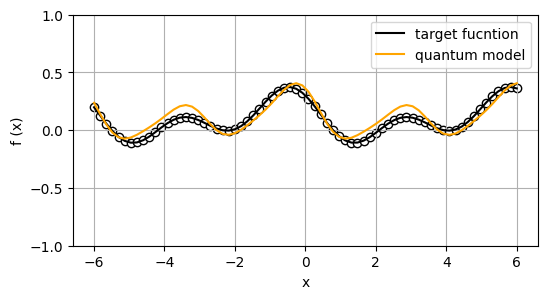

In [132]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [133]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_1)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.002647772565157544
Cost at step  10: 0.002372604600411112
Cost at step  15: 0.002536716168708969
Cost at step  20: 0.0011747030346931347
Cost at step  25: 0.0008689470962089935
Cost at step  30: 0.0008686268358960158
Cost at step  35: 0.0006443513930461754
Cost at step  40: 0.0002930666898533268
Cost at step  45: 0.00022561044592798605
Cost at step  50: 0.00018649359150239427
Cost at step  55: 7.42192866951299e-05
Cost at step  60: 0.00018311682420959965
Cost at step  65: 4.6406246251832594e-05
Cost at step  70: 4.73637404422465e-05
Cost at step  75: 8.885737368059056e-05
Cost at step  80: 1.1177047504089748e-05
Cost at step  85: 2.257499023460573e-05
Cost at step  90: 7.11352493867239e-05
Cost at step  95: 6.15507319035985e-05
Cost at step 100: 0.00020059703748416657
Cost at step 105: 9.950023041023079e-05
Cost at step 110: 0.0001540305881952376
Cost at step 115: 8.075296277766371e-05
Cost at step 120: 0.000623144169372758
Cost at step 125: 0.0003586672687874833
Co

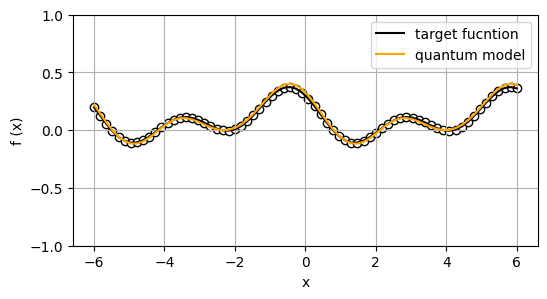

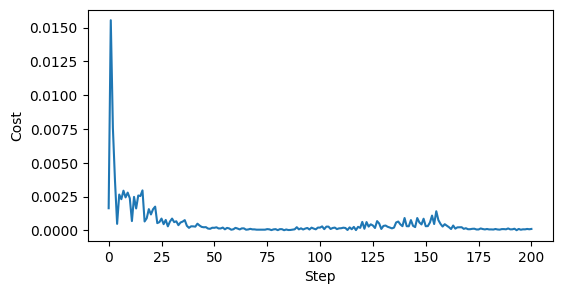

In [134]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [135]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Ansatz 2

In [136]:
### setting ansatz ###

ansatz = 2
n_qubits = 2
n_layers = 4
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_2(theta):
    """Trainable circuit block."""
    qcnn_unit9(theta[0],0,1)
    
@qml.qnode(dev)
def quantum_model_2(weights, x):

    for i in range(n_layers):
        W_2(weights[i])
        S(x)
    W_2(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [137]:
### show ansatz circuit ###

weights = 2 * np.pi * np.random.random(size=(n_layers+1, 1, 15), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_2, expansion_strategy="device")(weights,x_sample))

0: ──U3(2.46,1.73,4.60)─╭●──RY(0.21)─╭X──RY(0.75)─╭●──U3(5.03,1.82,0.22)──RX(-6.00)
1: ──U3(6.18,4.17,0.39)─╰X──RZ(5.89)─╰●───────────╰X──U3(5.82,0.19,2.46)──RX(-6.00)

───U3(1.52,3.68,0.63)─╭●──RY(2.95)─╭X──RY(1.36)─╭●──U3(3.29,4.44,3.26)──RX(-6.00)
───U3(4.31,3.32,1.57)─╰X──RZ(6.20)─╰●───────────╰X──U3(4.60,6.09,1.09)──RX(-6.00)

───U3(3.96,3.38,1.06)─╭●──RY(2.01)─╭X──RY(3.55)─╭●──U3(3.68,3.18,3.73)──RX(-6.00)
───U3(1.00,5.06,3.99)─╰X──RZ(4.04)─╰●───────────╰X──U3(3.21,3.62,1.61)──RX(-6.00)

───U3(2.16,1.04,3.67)─╭●──RY(4.37)─╭X──RY(4.82)─╭●──U3(1.59,1.71,1.33)──RX(-6.00)
───U3(3.87,6.06,5.60)─╰X──RZ(2.04)─╰●───────────╰X──U3(0.74,1.49,4.02)──RX(-6.00)

───U3(5.38,6.01,4.14)─╭●──RY(4.82)─╭X──RY(1.19)─╭●──U3(0.64,2.38,0.05)─┤  <Z>
───U3(2.24,3.42,4.19)─╰X──RZ(2.13)─╰●───────────╰X──U3(1.89,0.10,0.05)─┤     


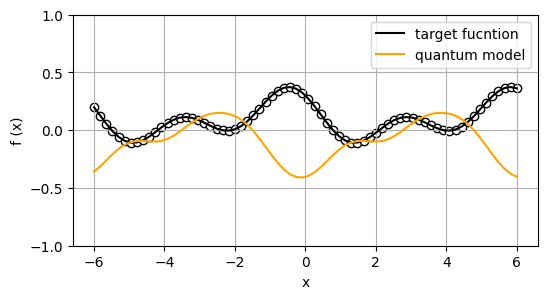

In [138]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [139]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_2)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.002333880017487864
Cost at step  10: 0.0016705500072542081
Cost at step  15: 0.0006582793176280122
Cost at step  20: 0.0013150210898787101
Cost at step  25: 0.0004192452541248427
Cost at step  30: 0.00022248343297329664
Cost at step  35: 0.0002477669129010722
Cost at step  40: 0.00016296249032488817
Cost at step  45: 0.00011151366884682126
Cost at step  50: 0.0001230835885474028
Cost at step  55: 9.704606922680775e-05
Cost at step  60: 6.981160030742166e-05
Cost at step  65: 8.372528242741326e-05
Cost at step  70: 3.9291895408684895e-05
Cost at step  75: 3.298717333168622e-05
Cost at step  80: 3.250545337903612e-05
Cost at step  85: 6.903607199455177e-05
Cost at step  90: 4.7202917691908134e-05
Cost at step  95: 2.7174506938166484e-05
Cost at step 100: 5.140985804052009e-05
Cost at step 105: 9.115547646492316e-06
Cost at step 110: 1.3262525963073714e-05
Cost at step 115: 1.038140454619632e-05
Cost at step 120: 1.055664774620622e-05
Cost at step 125: 8.86868307843518

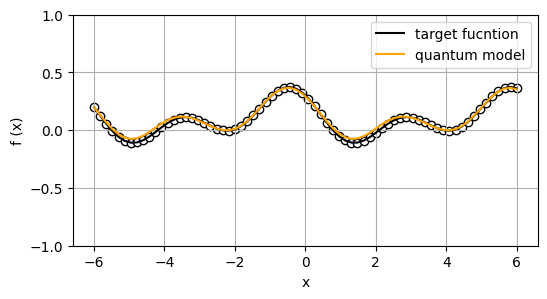

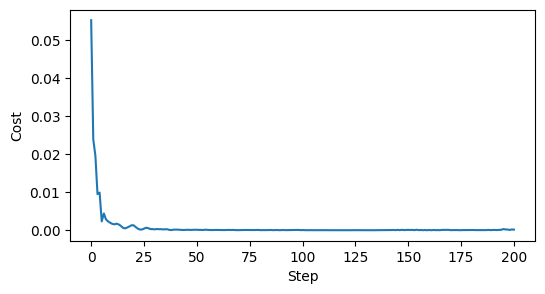

In [140]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='orange',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [141]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Final Plot

In [142]:
### load weights ###

weights1=np.load('./save/weight_hist_ansatz_1_degree_2_qubits_2_layers_4.npy')[-1]
weights2=np.load('./save/weight_hist_ansatz_2_degree_2_qubits_2_layers_4.npy')[-1]

predictions1 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights1,x_)))) for x_ in x]
predictions2 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights2,x_)))) for x_ in x]

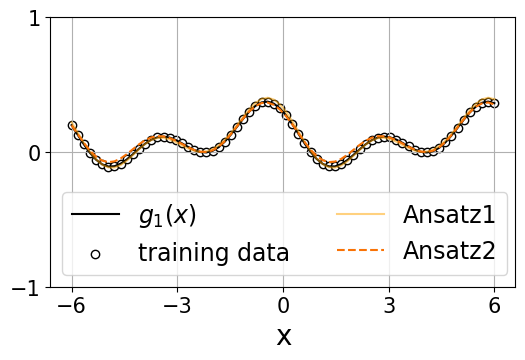

In [143]:
### final plot ###

plt.figure(figsize=(6,3.5))
plt.xlabel('x',fontsize=20)
plt.yticks([-1,0,1],fontsize=15)
plt.xticks([-6,-3,0,3,6],fontsize=15)
plt.plot(x, target_y, c='black',label=r'$g_1(x)$')
plt.scatter(x, target_y, facecolor='white', edgecolor='black',label='training data')
plt.plot(x, predictions1, c='#ffa500',label='Ansatz1',alpha=0.5)
plt.plot(x, predictions2, c='#f97306',label='Ansatz2',linestyle='--')
plt.ylim(-1,1)
plt.grid()
plt.legend(fontsize=17,ncols=2)
plt.show();

# $g_2(x)=\sum^3_{-3}c_k\exp(ikx)$ (7 modes) 

## target function

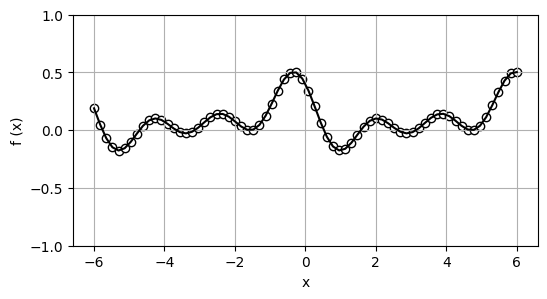

In [ ]:
### target function ###

degree = 3  # degree of the target function
scaling = 1  # scaling of the data
coeffs = [0.05 + 0.05j]*degree  # coefficients of non-zero frequencies
coeff0 = 0.1  # coefficient of zero frequency

def target_function(x):
    """Generate a truncated Fourier series, where the data gets re-scaled."""
    res = coeff0
    for idx, coeff in enumerate(coeffs):
        exponent = np.complex128(scaling * (idx+1) * x * 1j)
        conj_coeff = np.conjugate(coeff)
        res += coeff * np.exp(exponent) + conj_coeff * np.exp(-exponent)
    return np.real(res)

x = np.linspace(-6, 6, 70, requires_grad=False)
target_y = np.array([target_function(x_) for x_ in x], requires_grad=True)

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.ylim(-1, 1)
plt.grid()
plt.show();

## model 1 (2-qubit & 2-layer)
$$
|\Omega_{\text{target function}}|=7>|\Omega_{\text{model 1}}|=5
$$

### Ansatz 1

In [ ]:
### setting ansatz ###

ansatz = 1
n_qubits = 2
n_layers = 2
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_1(theta):
    """Trainable circuit block."""
    StronglyEntanglingLayers(theta, wires=range(n_qubits))

@qml.qnode(dev)
def quantum_model_1(weights, x):

    for i in range(n_layers):
        W_1(weights[i])
        S(x)
    W_1(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

trainable_block_layers = 3
weights = 2 * np.pi * np.random.random(size=(n_layers+1, trainable_block_layers, n_qubits, 3), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_1, expansion_strategy="device")(weights,x_sample))

0: ──Rot(4.10,4.96,0.11)─╭●─╭X──Rot(3.24,0.99,4.32)─╭●─╭X──Rot(0.89,5.75,0.93)─╭●─╭X──RX(-6.00)
1: ──Rot(0.79,5.66,6.19)─╰X─╰●──Rot(4.67,6.02,5.08)─╰X─╰●──Rot(1.82,1.52,5.53)─╰X─╰●──RX(-6.00)

───Rot(2.04,1.76,1.68)─╭●─╭X──Rot(3.08,0.33,1.26)─╭●─╭X──Rot(5.91,2.57,6.02)─╭●─╭X──RX(-6.00)
───Rot(3.37,1.80,1.64)─╰X─╰●──Rot(3.93,5.92,0.14)─╰X─╰●──Rot(3.79,3.21,3.57)─╰X─╰●──RX(-6.00)

───Rot(4.55,3.93,3.03)─╭●─╭X──Rot(2.11,4.91,5.26)─╭●─╭X──Rot(3.08,1.07,4.98)─╭●─╭X─┤  <Z>
───Rot(1.04,5.55,5.45)─╰X─╰●──Rot(1.07,0.01,4.87)─╰X─╰●──Rot(1.08,5.85,4.87)─╰X─╰●─┤     


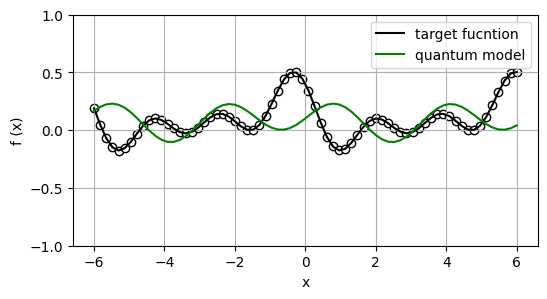

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_1)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.00735444237986157
Cost at step  10: 0.009414547475607066
Cost at step  15: 0.007371651565965359
Cost at step  20: 0.006201856230397547
Cost at step  25: 0.006690906827123624
Cost at step  30: 0.007707514945491531
Cost at step  35: 0.005658707933939453
Cost at step  40: 0.006263484976873836
Cost at step  45: 0.009563383808731115
Cost at step  50: 0.005442966714695974
Cost at step  55: 0.007465047117927647
Cost at step  60: 0.005736427642725052
Cost at step  65: 0.005956171093542173
Cost at step  70: 0.006640651118969965
Cost at step  75: 0.00701218215754133
Cost at step  80: 0.0062683741030654504
Cost at step  85: 0.0063485108814837305
Cost at step  90: 0.005611718702628927
Cost at step  95: 0.007925882368700905
Cost at step 100: 0.00846078970060941
Cost at step 105: 0.007016929271761011
Cost at step 110: 0.005670603049573478
Cost at step 115: 0.007506477852499194
Cost at step 120: 0.006401674084157198
Cost at step 125: 0.007982167428371626
Cost at step 130: 0.007660

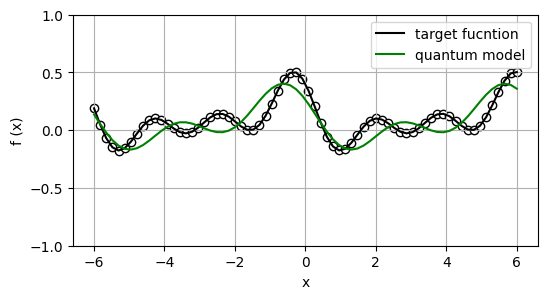

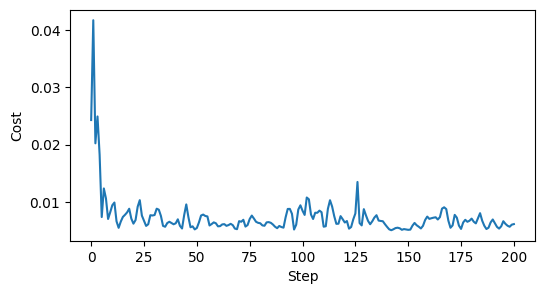

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Ansatz 2

In [ ]:
### setting ansatz ###

ansatz = 2
n_qubits = 2
n_layers = 2
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_2(theta):
    """Trainable circuit block."""
    qcnn_unit9(theta[0],0,1)

@qml.qnode(dev)
def quantum_model_2(weights, x):

    for i in range(n_layers):
        W_2(weights[i])
        S(x)
    W_2(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

weights = 2 * np.pi * np.random.random(size=(n_layers+1, 1, 15), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_2, expansion_strategy="device")(weights,x_sample))

0: ──U3(4.08,5.14,3.33)─╭●──RY(2.02)─╭X──RY(0.50)─╭●──U3(0.03,5.24,2.75)──RX(-6.00)
1: ──U3(3.10,3.80,2.51)─╰X──RZ(5.62)─╰●───────────╰X──U3(6.05,0.01,2.01)──RX(-6.00)

───U3(0.80,3.04,1.53)─╭●──RY(4.41)─╭X──RY(5.99)─╭●──U3(1.24,2.79,1.09)──RX(-6.00)
───U3(0.28,2.17,4.85)─╰X──RZ(5.69)─╰●───────────╰X──U3(3.34,1.98,5.01)──RX(-6.00)

───U3(1.72,6.03,6.20)─╭●──RY(4.19)─╭X──RY(0.98)─╭●──U3(5.56,2.82,5.77)─┤  <Z>
───U3(4.79,3.94,1.42)─╰X──RZ(4.68)─╰●───────────╰X──U3(3.58,4.24,1.52)─┤     


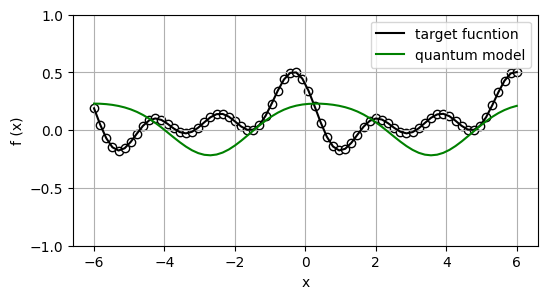

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_2)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

/opt/homebrew/Caskroom/miniforge/base/envs/newdqc/lib/python3.9/site-packages/autograd/numpy/numpy_vjps.py:698: ComplexWarning: Casting complex values to real discards the imaginary part
  onp.add.at(A, idx, x)


Cost at step   5: 0.009457493485819375
Cost at step  10: 0.009291357018108196
Cost at step  15: 0.006074956337853505
Cost at step  20: 0.006323261627088726
Cost at step  25: 0.006296841496983271
Cost at step  30: 0.007751402654656037
Cost at step  35: 0.006697247788695066
Cost at step  40: 0.006005851276942103
Cost at step  45: 0.007678238995393281
Cost at step  50: 0.006287557674245067
Cost at step  55: 0.006267056552631151
Cost at step  60: 0.005868432306001902
Cost at step  65: 0.005407387015631542
Cost at step  70: 0.005172430823343162
Cost at step  75: 0.005554828277731701
Cost at step  80: 0.006741643190276772
Cost at step  85: 0.0051369392416927345
Cost at step  90: 0.00601094246677203
Cost at step  95: 0.005309911270395266
Cost at step 100: 0.005654559802470624
Cost at step 105: 0.006103807572187122
Cost at step 110: 0.00810666407253393
Cost at step 115: 0.0073073086757521714
Cost at step 120: 0.006314234779937756
Cost at step 125: 0.007111497034509879
Cost at step 130: 0.00511

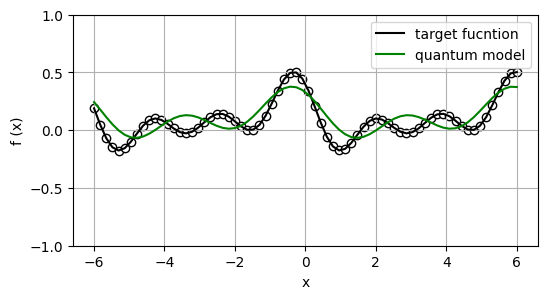

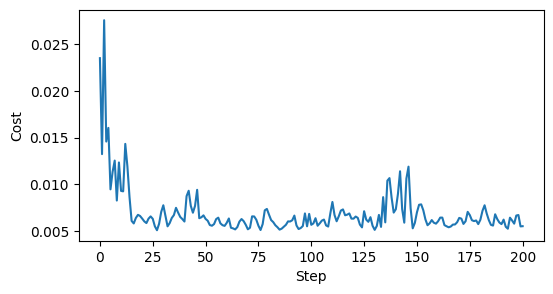

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Final Plot

In [ ]:
### load weights ###

weights1=np.load('./save/weight_hist_ansatz_1_degree_3_qubits_2_layers_2.npy')[-1]
weights2=np.load('./save/weight_hist_ansatz_2_degree_3_qubits_2_layers_2.npy')[-1]

predictions1 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights1,x_)))) for x_ in x]
predictions2 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights2,x_)))) for x_ in x]

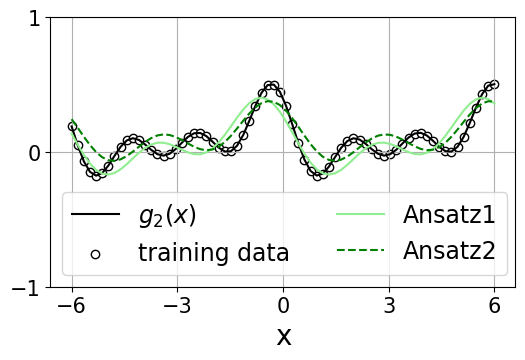

In [ ]:
### final plot ###

plt.figure(figsize=(6,3.5))
plt.xlabel('x',fontsize=20)
plt.yticks([-1,0,1],fontsize=15)
plt.xticks([-6,-3,0,3,6],fontsize=15)
plt.plot(x, target_y, c='black',label=r'$g_2(x)$')
plt.scatter(x, target_y, facecolor='white', edgecolor='black',label='training data')
plt.plot(x, predictions1, c='#90EE90',label='Ansatz1',alpha=1)
plt.plot(x, predictions2, c='#008000',label='Ansatz2',linestyle='--')
plt.ylim(-1,1)
plt.grid()
plt.legend(fontsize=17,ncols=2)
plt.show();

## model 2 (3-qubit & 2-layer)
$$
|\Omega_{\text{target function}}|=7=|\Omega_{\text{model 2}}|
$$

### Ansatz 1

In [ ]:
### setting ansatz ###

ansatz = 1
n_qubits = 3
n_layers = 2
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_1(theta):
    """Trainable circuit block."""
    StronglyEntanglingLayers(theta, wires=range(n_qubits))

@qml.qnode(dev)
def quantum_model_1(weights, x):

    for i in range(n_layers):
        W_1(weights[i])
        S(x)
    W_1(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

trainable_block_layers = 3
weights = 2 * np.pi * np.random.random(size=(n_layers+1, trainable_block_layers, n_qubits, 3), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_1, expansion_strategy="device")(weights,x_sample))

0: ──Rot(1.56,2.69,5.81)─╭●────╭X──Rot(4.66,1.83,5.67)─╭●─╭X──Rot(4.41,4.28,1.74)
1: ──Rot(1.49,0.10,1.32)─╰X─╭●─│───Rot(1.32,0.04,4.39)─│──╰●─╭X──────────────────
2: ──Rot(4.20,4.49,5.99)────╰X─╰●──Rot(3.85,2.44,3.00)─╰X────╰●──────────────────

───────────────────────╭●────╭X──RX(-6.00)──Rot(1.23,5.78,4.19)─╭●────╭X──Rot(1.66,0.62,1.31)─╭●─╭X
───Rot(2.57,1.88,2.86)─╰X─╭●─│───RX(-6.00)──Rot(1.77,4.04,5.34)─╰X─╭●─│───Rot(4.13,2.62,5.05)─│──╰●
───Rot(5.13,3.55,1.46)────╰X─╰●──RX(-6.00)──Rot(5.88,6.12,4.72)────╰X─╰●──Rot(4.10,1.72,1.40)─╰X───

───Rot(5.61,3.40,0.82)──────────────────────╭●────╭X──RX(-6.00)──Rot(0.25,2.35,5.40)─╭●────╭X
──╭X────────────────────Rot(2.18,5.38,4.35)─╰X─╭●─│───RX(-6.00)──Rot(3.01,1.90,1.72)─╰X─╭●─│─
──╰●────────────────────Rot(5.66,6.19,2.58)────╰X─╰●──RX(-6.00)──Rot(2.41,5.91,3.28)────╰X─╰●

───Rot(2.02,5.01,4.43)─╭●─╭X──Rot(6.26,3.95,4.20)──────────────────────╭●────╭X─┤  <Z>
───Rot(4.03,2.91,2.79)─│──╰●─╭X────────────────────Rot(5.04,2.68,2.04)─╰X─╭●─│──┤ 

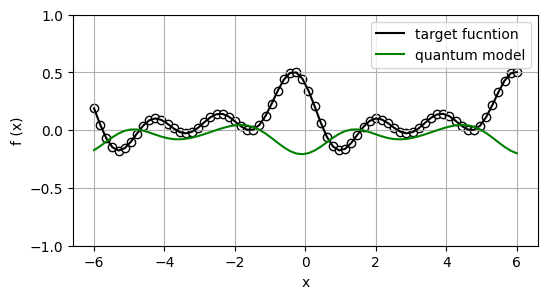

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_1)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.004700442779592968
Cost at step  10: 0.0028665312441271866
Cost at step  15: 0.0015387141395123579
Cost at step  20: 0.0013335629602468243
Cost at step  25: 0.0011723032694211273
Cost at step  30: 0.0013302153390528778
Cost at step  35: 0.0006209602401188246
Cost at step  40: 0.0006326796093404715
Cost at step  45: 0.00020753221280170564
Cost at step  50: 0.0001604222569520358
Cost at step  55: 7.141930092293315e-05
Cost at step  60: 3.388251111447511e-05
Cost at step  65: 2.8395497828513732e-05
Cost at step  70: 1.5099489334253069e-05
Cost at step  75: 1.9001337322346637e-05
Cost at step  80: 2.9487673331487586e-05
Cost at step  85: 2.0457771569952614e-05
Cost at step  90: 1.1130094195792278e-05
Cost at step  95: 5.4396059517977505e-06
Cost at step 100: 3.0313763253781205e-06
Cost at step 105: 5.294583564763431e-06
Cost at step 110: 1.1319247344430396e-06
Cost at step 115: 3.110985244819855e-06
Cost at step 120: 3.2680963878562718e-06
Cost at step 125: 1.3841232338

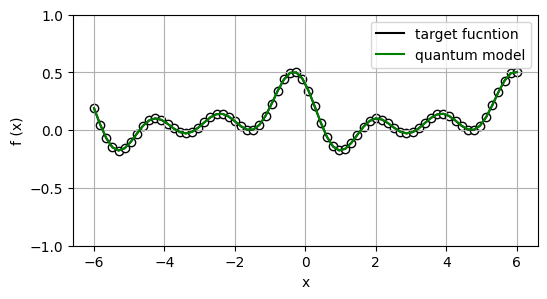

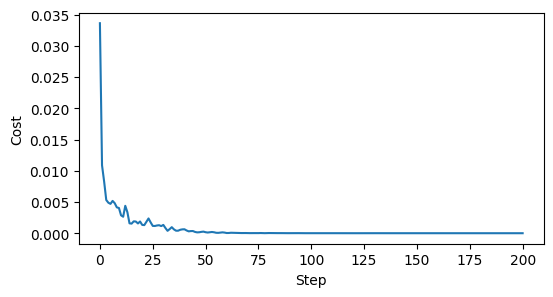

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Ansatz 2

In [ ]:
### setting ansatz ###

ansatz = 2
n_qubits = 3
n_layers = 2
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_2(theta):
    """Trainable circuit block."""
    qcnn_unit9(theta[0],0,1)
    qcnn_unit9(theta[1],1,2)
    
@qml.qnode(dev)
def quantum_model_2(weights, x):

    for i in range(n_layers):
        W_2(weights[i])
        S(x)
    W_2(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

weights = 2 * np.pi * np.random.random(size=(n_layers+1, 2,15), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_2, expansion_strategy="device")(weights,x_sample))

0: ──U3(1.60,0.35,2.81)─╭●──RY(3.02)─╭X──RY(1.04)─╭●──U3(4.09,1.79,0.88)──RX(-6.00)─────────
1: ──U3(1.42,5.88,5.31)─╰X──RZ(6.17)─╰●───────────╰X──U3(2.89,6.21,4.27)──U3(2.71,5.92,5.79)
2: ──U3(4.60,3.00,1.27)─────────────────────────────────────────────────────────────────────

───U3(1.08,2.95,5.90)─────────────────────────────────────────────────────────────────────────────
──╭●───────────────────RY(0.77)─╭X──RY(4.07)─╭●──U3(2.98,3.22,0.52)──RX(-6.00)──U3(1.18,4.38,4.43)
──╰X───────────────────RZ(6.16)─╰●───────────╰X──U3(2.91,3.22,0.16)──RX(-6.00)──U3(0.49,3.41,2.22)

──╭●──RY(0.69)─╭X──RY(3.59)─╭●──U3(3.89,3.89,2.06)──RX(-6.00)───────────U3(3.42,5.17,1.88)──────────
──╰X──RZ(3.73)─╰●───────────╰X──U3(5.48,3.62,4.69)──U3(2.23,0.61,6.22)─╭●───────────────────RY(2.75)
───────────────────────────────────────────────────────────────────────╰X───────────────────RZ(2.11)

─────────────────────────────────────────────────────────────────────╭●──RY(5.86)─╭X──RY(5.92)─╭●
──╭X──RY(3.56)─╭●──U

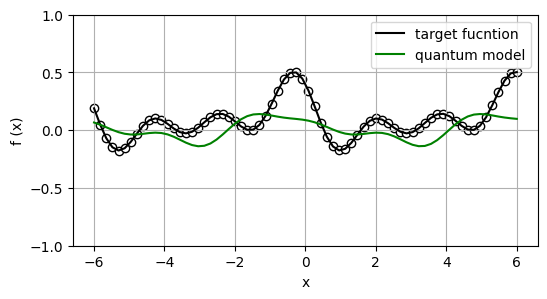

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_2)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.00734716717326335
Cost at step  10: 0.005376920225742735
Cost at step  15: 0.00542712742657038
Cost at step  20: 0.005750362565519017
Cost at step  25: 0.0022109786579474185
Cost at step  30: 0.001008394709898654
Cost at step  35: 0.0006341985169618757
Cost at step  40: 0.00044942601832134987
Cost at step  45: 0.00034961916220675846
Cost at step  50: 0.00017229506885683496
Cost at step  55: 0.0001299231918213332
Cost at step  60: 0.00011062302615279004
Cost at step  65: 0.00017054260835215536
Cost at step  70: 9.044662427660263e-05
Cost at step  75: 7.144014453852215e-05
Cost at step  80: 3.235104866256597e-05
Cost at step  85: 6.082505953768958e-05
Cost at step  90: 1.884250075811301e-05
Cost at step  95: 1.4837043968018168e-05
Cost at step 100: 3.941834205153939e-06
Cost at step 105: 1.3423787249241818e-05
Cost at step 110: 8.342466511943492e-06
Cost at step 115: 1.217215850126423e-05
Cost at step 120: 7.213720293046164e-06
Cost at step 125: 2.215152163385003e-06


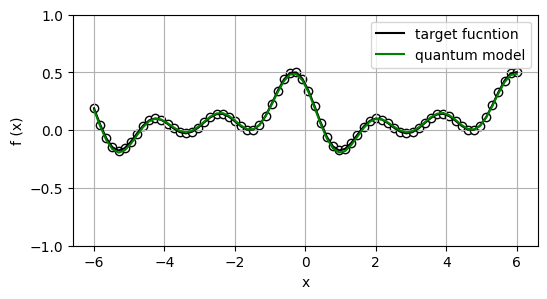

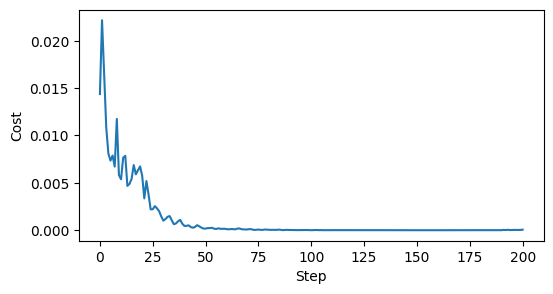

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Final Plot

In [ ]:
### load weights ###

weights1=np.load('./save/weight_hist_ansatz_1_degree_3_qubits_3_layers_2.npy')[-1]
weights2=np.load('./save/weight_hist_ansatz_2_degree_3_qubits_3_layers_2.npy')[-1]

predictions1 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights1,x_)))) for x_ in x]
predictions2 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights2,x_)))) for x_ in x]

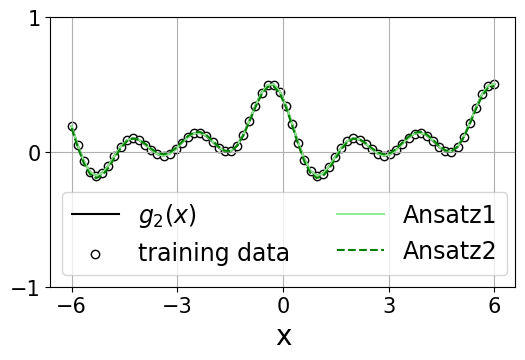

In [ ]:
### final plot ###

plt.figure(figsize=(6,3.5))
plt.xlabel('x',fontsize=20)
plt.yticks([-1,0,1],fontsize=15)
plt.xticks([-6,-3,0,3,6],fontsize=15)
plt.plot(x, target_y, c='black',label=r'$g_2(x)$')
plt.scatter(x, target_y, facecolor='white', edgecolor='black',label='training data')
plt.plot(x, predictions1, c='#90EE90',label='Ansatz1',alpha=1)
plt.plot(x, predictions2, c='#008000',label='Ansatz2',linestyle='--')
plt.ylim(-1,1)
plt.grid()
plt.legend(fontsize=17,ncols=2)
plt.show();

## model 3 (2-qubit & 3-layer)
$$
|\Omega_{\text{target function}}|=7=|\Omega_{\text{model 3}}|
$$

### Ansatz 1

In [ ]:
### setting ansatz ###

ansatz = 1
n_qubits = 2
n_layers = 3
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_1(theta):
    """Trainable circuit block."""
    StronglyEntanglingLayers(theta, wires=range(n_qubits))

@qml.qnode(dev)
def quantum_model_1(weights, x):

    for i in range(n_layers):
        W_1(weights[i])
        S(x)
    W_1(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

trainable_block_layers = 3
weights = 2 * np.pi * np.random.random(size=(n_layers+1, trainable_block_layers, n_qubits, 3), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_1, expansion_strategy="device")(weights,x_sample))

0: ──Rot(0.78,3.19,0.91)─╭●─╭X──Rot(3.20,4.67,4.91)─╭●─╭X──Rot(0.40,0.90,1.73)─╭●─╭X──RX(-6.00)
1: ──Rot(1.67,0.05,0.02)─╰X─╰●──Rot(3.25,1.48,4.65)─╰X─╰●──Rot(1.38,0.36,3.16)─╰X─╰●──RX(-6.00)

───Rot(4.20,5.21,1.89)─╭●─╭X──Rot(2.11,2.63,0.02)─╭●─╭X──Rot(1.12,2.12,5.42)─╭●─╭X──RX(-6.00)
───Rot(3.52,2.56,2.78)─╰X─╰●──Rot(5.30,2.78,5.27)─╰X─╰●──Rot(5.17,5.01,4.05)─╰X─╰●──RX(-6.00)

───Rot(0.72,2.51,0.49)─╭●─╭X──Rot(4.36,1.82,3.63)─╭●─╭X──Rot(3.03,1.24,0.14)─╭●─╭X──RX(-6.00)
───Rot(2.16,4.71,2.46)─╰X─╰●──Rot(6.28,0.58,6.07)─╰X─╰●──Rot(3.84,0.75,2.51)─╰X─╰●──RX(-6.00)

───Rot(0.47,3.18,2.88)─╭●─╭X──Rot(1.09,3.18,1.93)─╭●─╭X──Rot(4.87,4.53,5.04)─╭●─╭X─┤  <Z>
───Rot(2.98,0.36,2.72)─╰X─╰●──Rot(1.53,6.22,4.09)─╰X─╰●──Rot(5.08,0.90,0.11)─╰X─╰●─┤     


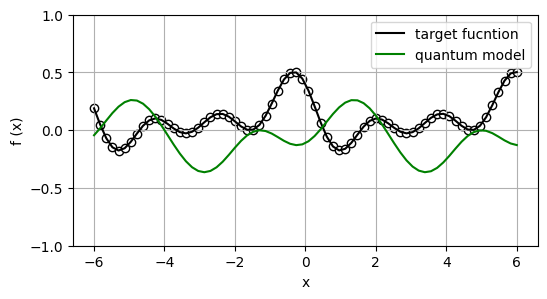

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_1)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.008232794966425788
Cost at step  10: 0.00546171301642009
Cost at step  15: 0.00788172547311787
Cost at step  20: 0.0024833357943947953
Cost at step  25: 0.0029509080112481933
Cost at step  30: 0.0011498373140805542
Cost at step  35: 0.0012317855024310117
Cost at step  40: 0.0013013993454378775
Cost at step  45: 0.00032936417588902384
Cost at step  50: 0.0008127371023603944
Cost at step  55: 0.0003860705841481526
Cost at step  60: 0.00032991326136437154
Cost at step  65: 7.482992140665263e-05
Cost at step  70: 5.534736863293844e-05
Cost at step  75: 0.00011686729475661915
Cost at step  80: 4.681617172019425e-05
Cost at step  85: 5.6633863641815816e-05
Cost at step  90: 3.399340969698499e-05
Cost at step  95: 1.6409752230789612e-05
Cost at step 100: 1.30124729432047e-05
Cost at step 105: 3.6612777904809386e-06
Cost at step 110: 6.203512010515842e-06
Cost at step 115: 1.120309272410307e-05
Cost at step 120: 4.453103383151469e-06
Cost at step 125: 1.1607079700679078e-05

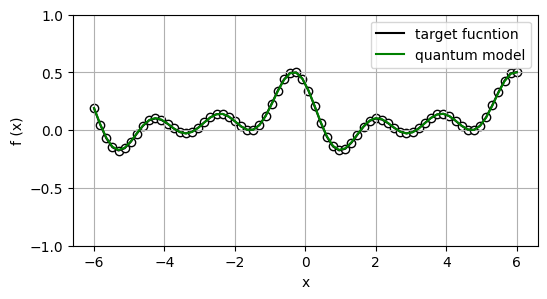

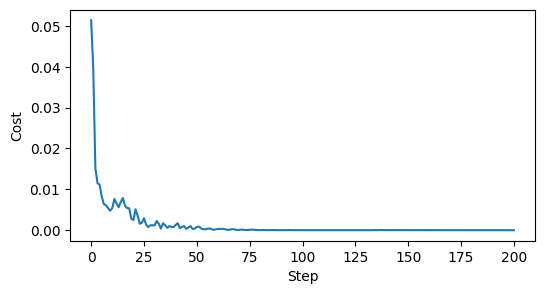

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Ansatz 2

In [ ]:
### setting ansatz ###

ansatz = 2
n_qubits = 2
n_layers = 3
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_2(theta):
    """Trainable circuit block."""
    qcnn_unit9(theta[0],0,1)
    
@qml.qnode(dev)
def quantum_model_2(weights, x):

    for i in range(n_layers):
        W_2(weights[i])
        S(x)
    W_2(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

weights = 2 * np.pi * np.random.random(size=(n_layers+1, 1, 15), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_2, expansion_strategy="device")(weights,x_sample))

0: ──U3(3.50,2.86,5.68)─╭●──RY(3.03)─╭X──RY(5.01)─╭●──U3(4.83,4.72,2.63)──RX(-6.00)
1: ──U3(1.97,1.02,4.92)─╰X──RZ(4.82)─╰●───────────╰X──U3(0.01,5.16,3.16)──RX(-6.00)

───U3(5.79,2.65,1.67)─╭●──RY(4.09)─╭X──RY(5.10)─╭●──U3(3.41,3.78,5.65)──RX(-6.00)
───U3(5.13,3.09,3.32)─╰X──RZ(4.99)─╰●───────────╰X──U3(1.59,4.64,3.46)──RX(-6.00)

───U3(2.76,5.16,0.56)─╭●──RY(4.95)─╭X──RY(3.19)─╭●──U3(3.48,3.02,5.80)──RX(-6.00)
───U3(1.87,6.11,6.26)─╰X──RZ(3.30)─╰●───────────╰X──U3(2.94,5.21,0.24)──RX(-6.00)

───U3(4.11,0.67,1.21)─╭●──RY(3.45)─╭X──RY(5.89)─╭●──U3(4.47,5.77,4.82)─┤  <Z>
───U3(1.29,3.63,4.02)─╰X──RZ(0.40)─╰●───────────╰X──U3(0.90,2.16,2.88)─┤     


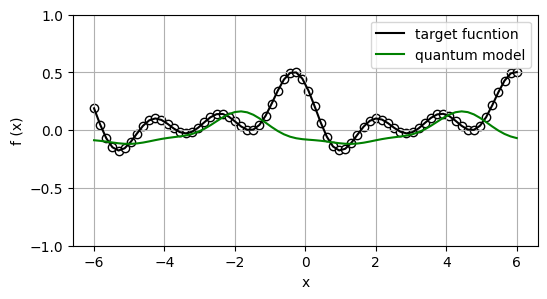

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_2)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.005388797652898729
Cost at step  10: 0.0029717368115586987
Cost at step  15: 0.0011200145077123209
Cost at step  20: 0.0006669141751348189
Cost at step  25: 0.0005628103513724716
Cost at step  30: 0.00020923816802112096
Cost at step  35: 0.0001621484825019621
Cost at step  40: 0.0001559536355780123
Cost at step  45: 0.0002703817185072935
Cost at step  50: 0.00036168016048979265
Cost at step  55: 0.00014044913941119614
Cost at step  60: 0.00017084729304618455
Cost at step  65: 9.79140191054384e-05
Cost at step  70: 8.521889901894822e-05
Cost at step  75: 4.166633209939718e-05
Cost at step  80: 1.364639667119883e-05
Cost at step  85: 2.164098686262222e-05
Cost at step  90: 2.276976261818401e-05
Cost at step  95: 2.5266364009789743e-05
Cost at step 100: 2.320113269087562e-05
Cost at step 105: 1.4620755087370631e-05
Cost at step 110: 9.748425052105152e-06
Cost at step 115: 8.638885100441741e-06
Cost at step 120: 5.963396996849137e-06
Cost at step 125: 1.3955214983727695

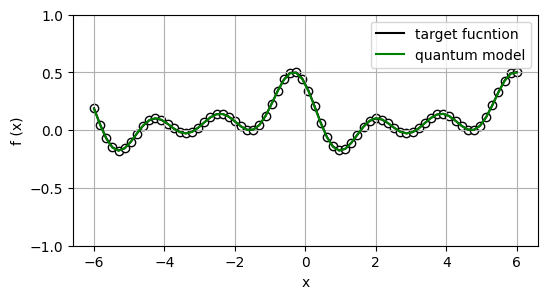

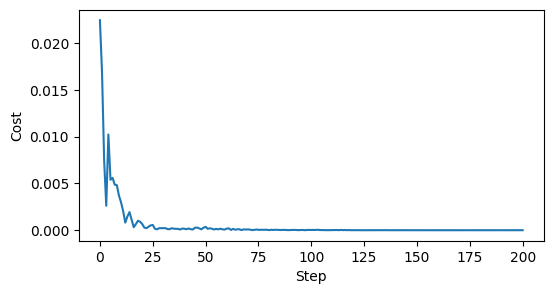

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Final Plot

In [ ]:
### load weights ###

weights1=np.load('./save/weight_hist_ansatz_1_degree_3_qubits_2_layers_3.npy')[-1]
weights2=np.load('./save/weight_hist_ansatz_2_degree_3_qubits_2_layers_3.npy')[-1]

predictions1 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights1,x_)))) for x_ in x]
predictions2 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights2,x_)))) for x_ in x]

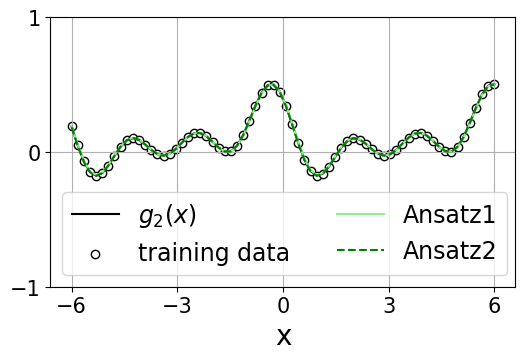

In [ ]:
### final plot ###

plt.figure(figsize=(6,3.5))
plt.xlabel('x',fontsize=20)
plt.yticks([-1,0,1],fontsize=15)
plt.xticks([-6,-3,0,3,6],fontsize=15)
plt.plot(x, target_y, c='black',label=r'$g_2(x)$')
plt.scatter(x, target_y, facecolor='white', edgecolor='black',label='training data')
plt.plot(x, predictions1, c='#90EE90',label='Ansatz1',alpha=1)
plt.plot(x, predictions2, c='#008000',label='Ansatz2',linestyle='--')
plt.ylim(-1,1)
plt.grid()
plt.legend(fontsize=17,ncols=2)
plt.show();

## model 4 (4-qubit & 2-layer)
$$
|\Omega_{\text{target function}}|=7<|\Omega_{\text{model 4}}|=9
$$

### Ansatz 1

In [ ]:
### setting ansatz ###

ansatz = 1
n_qubits = 4
n_layers = 2
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_1(theta):
    """Trainable circuit block."""
    StronglyEntanglingLayers(theta, wires=range(n_qubits))

@qml.qnode(dev)
def quantum_model_1(weights, x):

    for i in range(n_layers):
        W_1(weights[i])
        S(x)
    W_1(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

trainable_block_layers = 3
weights = 2 * np.pi * np.random.random(size=(n_layers+1, trainable_block_layers, n_qubits, 3), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_1, expansion_strategy="device")(weights,x_sample))

0: ──Rot(2.81,1.47,2.22)─╭●───────╭X──Rot(2.67,5.85,3.00)─╭●────╭X──Rot(2.44,3.12,5.61)
1: ──Rot(3.31,0.88,4.69)─╰X─╭●────│───Rot(2.00,2.46,4.50)─│──╭●─│──╭X──────────────────
2: ──Rot(2.38,2.32,1.50)────╰X─╭●─│───Rot(4.01,4.04,2.14)─╰X─│──╰●─│───────────────────
3: ──Rot(5.59,4.12,1.82)───────╰X─╰●──Rot(5.55,4.70,5.38)────╰X────╰●──────────────────

───────────────────────╭●─╭X──RX(-6.00)──Rot(5.35,1.31,0.76)─────────────────────
───Rot(2.65,3.98,2.32)─│──╰●─╭X──────────RX(-6.00)────────────Rot(1.97,3.37,0.66)
───Rot(0.28,4.60,2.85)─│─────╰●─────────╭X────────────────────RX(-6.00)──────────
───Rot(0.72,2.44,3.91)─╰X───────────────╰●────────────────────RX(-6.00)──────────

──╭●─────────────────────────╭X──Rot(0.49,1.73,3.78)─╭●────╭X──Rot(0.95,5.25,3.71)
──╰X───────────────────╭●────│───Rot(3.01,4.42,6.23)─│──╭●─│──╭X──────────────────
───Rot(0.16,2.45,1.90)─╰X─╭●─│───Rot(0.74,3.31,3.00)─╰X─│──╰●─│───────────────────
───Rot(2.76,6.00,1.78)────╰X─╰●──Rot(4.52,0.63,4.92)────╰X────╰●─────

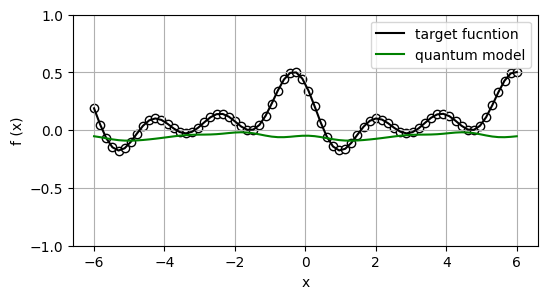

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_1)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.0050276435142737885
Cost at step  10: 0.005090192513474273
Cost at step  15: 0.002269148052175026
Cost at step  20: 0.0019402038370373571
Cost at step  25: 0.0014576737697753737
Cost at step  30: 0.000811671393578396
Cost at step  35: 0.000709414231328862
Cost at step  40: 0.00042556442443266254
Cost at step  45: 0.0005453051426842496
Cost at step  50: 0.0002708417442180295
Cost at step  55: 0.00022078404156625979
Cost at step  60: 0.00010146391668353966
Cost at step  65: 5.515453946002862e-05
Cost at step  70: 6.143489906021951e-05
Cost at step  75: 4.652614864948657e-05
Cost at step  80: 5.3051249798082065e-05
Cost at step  85: 0.0001101331909139353
Cost at step  90: 1.6616634465087034e-05
Cost at step  95: 3.6031384793697544e-05
Cost at step 100: 2.5558434999682405e-05
Cost at step 105: 5.006742542244375e-05
Cost at step 110: 1.2194926190728006e-05
Cost at step 115: 5.559663491028905e-06
Cost at step 120: 2.1711690695476585e-05
Cost at step 125: 1.229872436494700

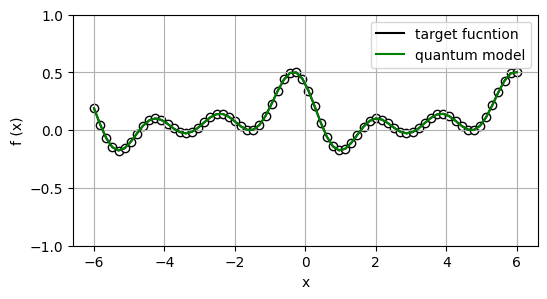

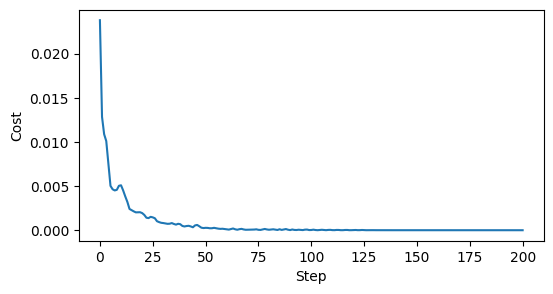

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Ansatz 2

In [ ]:
### setting ansatz ###

ansatz = 2
n_qubits = 4
n_layers = 2
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_2(theta):
    """Trainable circuit block."""
    qcnn_unit9(theta[0],0,1)
    qcnn_unit9(theta[1],2,3)
    qcnn_unit9(theta[2],1,2)
    qcnn_unit9(theta[3],3,0)
    
@qml.qnode(dev)
def quantum_model_2(weights, x):

    for i in range(n_layers):
        W_2(weights[i])
        S(x)
    W_2(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

weights = 2 * np.pi * np.random.random(size=(n_layers+1, 4, 15), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_2, expansion_strategy="device")(weights,x_sample))

0: ──U3(0.79,1.95,6.25)─╭●──RY(1.34)─╭X──RY(5.38)─╭●──U3(1.10,2.85,1.80)──U3(1.91,4.59,5.09)───
1: ──U3(5.31,4.74,4.37)─╰X──RZ(5.45)─╰●───────────╰X──U3(3.15,0.16,4.71)──U3(5.68,5.48,4.74)─╭●
2: ──U3(3.30,5.41,2.53)─╭●──RY(2.74)─╭X──RY(3.27)─╭●──U3(6.18,1.35,1.97)──U3(2.01,5.61,1.51)─╰X
3: ──U3(2.83,1.65,1.86)─╰X──RZ(4.53)─╰●───────────╰X──U3(3.01,3.76,2.80)──U3(0.82,1.26,2.67)───

────────────────────────────────────────────────╭X──RZ(6.07)─╭●───────────╭X──U3(4.47,3.20,0.58)
───RY(0.91)─╭X──RY(5.33)─╭●──U3(4.21,0.27,4.99)─│────────────│────────────│───RX(-6.00)─────────
───RZ(0.77)─╰●───────────╰X──U3(1.63,2.80,1.37)─│────────────│────────────│───RX(-6.00)─────────
────────────────────────────────────────────────╰●──RY(0.21)─╰X──RY(2.13)─╰●──U3(0.87,3.95,0.86)

───RX(-6.00)───────────U3(3.44,2.88,3.94)─╭●──RY(3.18)─╭X──RY(0.92)─╭●──U3(3.24,4.97,3.06)
───U3(4.68,3.81,0.31)─────────────────────╰X──RZ(3.22)─╰●───────────╰X──U3(3.45,2.83,5.02)
───U3(2.14,1.94,3.64)─────────────────────╭●

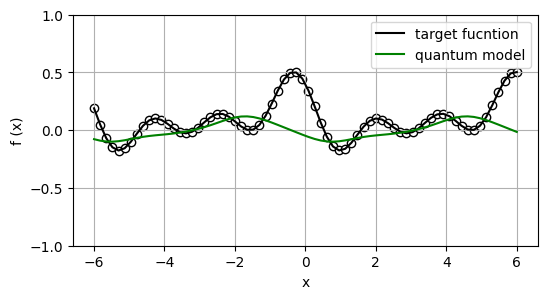

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_2)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.017732763344031767
Cost at step  10: 0.025926749605720018
Cost at step  15: 0.021375211551389894
Cost at step  20: 0.017056137216094093
Cost at step  25: 0.012560874946457742
Cost at step  30: 0.006897884966028934
Cost at step  35: 0.0045677185802012864
Cost at step  40: 0.002648415578762164
Cost at step  45: 0.002034554998331084
Cost at step  50: 0.000997771635399433
Cost at step  55: 0.00048820369612519464
Cost at step  60: 0.00031175768362598814
Cost at step  65: 0.0002227716447644316
Cost at step  70: 0.0001677102277441883
Cost at step  75: 9.896068238956998e-05
Cost at step  80: 0.0001409520144865789
Cost at step  85: 5.129877970676562e-05
Cost at step  90: 4.173759170491898e-05
Cost at step  95: 5.281444144566037e-05
Cost at step 100: 3.2430502078150464e-05
Cost at step 105: 9.643240790437383e-06
Cost at step 110: 7.390544580319306e-06
Cost at step 115: 6.73762720767394e-06
Cost at step 120: 2.3017224303730936e-06
Cost at step 125: 2.862796017875226e-06
Cost a

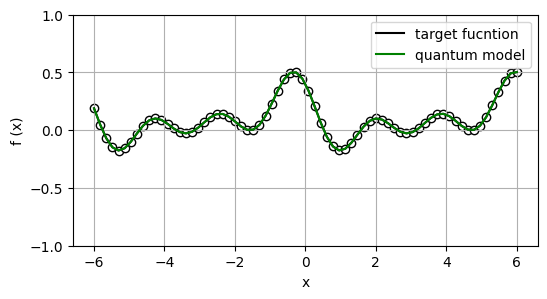

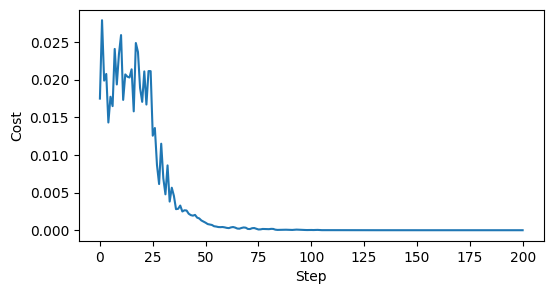

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Final Plot

In [ ]:
### load weights ###

weights1=np.load('./save/weight_hist_ansatz_1_degree_3_qubits_4_layers_2.npy')[-1]
weights2=np.load('./save/weight_hist_ansatz_2_degree_3_qubits_4_layers_2.npy')[-1]

predictions1 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights1,x_)))) for x_ in x]
predictions2 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights2,x_)))) for x_ in x]

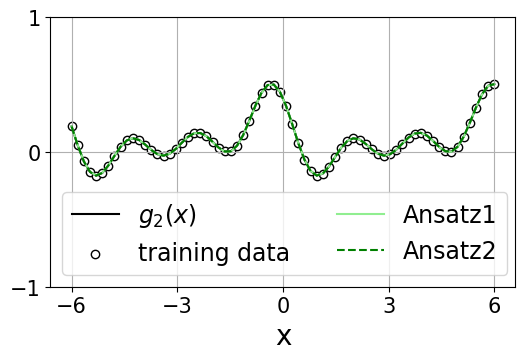

In [ ]:
### final plot ###

plt.figure(figsize=(6,3.5))
plt.xlabel('x',fontsize=20)
plt.yticks([-1,0,1],fontsize=15)
plt.xticks([-6,-3,0,3,6],fontsize=15)
plt.plot(x, target_y, c='black',label=r'$g_2(x)$')
plt.scatter(x, target_y, facecolor='white', edgecolor='black',label='training data')
plt.plot(x, predictions1, c='#90EE90',label='Ansatz1',alpha=1)
plt.plot(x, predictions2, c='#008000',label='Ansatz2',linestyle='--')
plt.ylim(-1,1)
plt.grid()
plt.legend(fontsize=17,ncols=2)
plt.show();

## model 5 (2-qubit & 4-layer)
$$
|\Omega_{\text{target function}}|=7<|\Omega_{\text{model 5}}|=9
$$

### Ansatz 1

In [ ]:
### setting ansatz ###

ansatz = 1
n_qubits = 2
n_layers = 4
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_1(theta):
    """Trainable circuit block."""
    StronglyEntanglingLayers(theta, wires=range(n_qubits))

@qml.qnode(dev)
def quantum_model_1(weights, x):

    for i in range(n_layers):
        W_1(weights[i])
        S(x)
    W_1(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

trainable_block_layers = 3
weights = 2 * np.pi * np.random.random(size=(n_layers+1, trainable_block_layers, n_qubits, 3), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_1, expansion_strategy="device")(weights,x_sample))

0: ──Rot(0.18,5.68,2.14)─╭●─╭X──Rot(0.07,0.09,3.77)─╭●─╭X──Rot(4.39,0.57,2.10)─╭●─╭X──RX(-6.00)
1: ──Rot(1.54,3.40,4.05)─╰X─╰●──Rot(3.16,5.86,2.33)─╰X─╰●──Rot(4.76,4.45,0.91)─╰X─╰●──RX(-6.00)

───Rot(4.15,1.69,4.08)─╭●─╭X──Rot(2.95,2.09,2.75)─╭●─╭X──Rot(1.29,1.28,2.47)─╭●─╭X──RX(-6.00)
───Rot(0.80,2.65,5.91)─╰X─╰●──Rot(4.82,2.95,4.97)─╰X─╰●──Rot(3.80,4.43,0.75)─╰X─╰●──RX(-6.00)

───Rot(2.03,3.36,2.45)─╭●─╭X──Rot(2.12,4.24,6.24)─╭●─╭X──Rot(5.62,3.75,4.98)─╭●─╭X──RX(-6.00)
───Rot(2.22,1.06,0.69)─╰X─╰●──Rot(4.80,1.50,5.21)─╰X─╰●──Rot(2.38,0.72,4.64)─╰X─╰●──RX(-6.00)

───Rot(2.79,3.13,1.67)─╭●─╭X──Rot(0.23,4.87,2.23)─╭●─╭X──Rot(2.08,2.06,2.33)─╭●─╭X──RX(-6.00)
───Rot(4.42,3.87,2.36)─╰X─╰●──Rot(3.08,5.85,3.69)─╰X─╰●──Rot(0.54,3.01,4.74)─╰X─╰●──RX(-6.00)

───Rot(4.11,5.84,0.27)─╭●─╭X──Rot(2.16,3.71,3.34)─╭●─╭X──Rot(5.63,5.38,2.86)─╭●─╭X─┤  <Z>
───Rot(3.86,1.20,2.69)─╰X─╰●──Rot(5.71,3.81,3.73)─╰X─╰●──Rot(5.58,4.25,0.95)─╰X─╰●─┤     


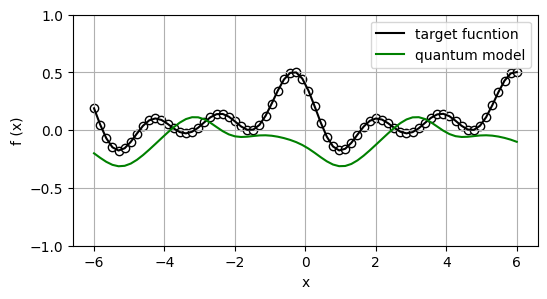

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_1)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.0011809720356716809
Cost at step  10: 0.0035468519110902455
Cost at step  15: 0.0012068636800065089
Cost at step  20: 0.0008004727831206997
Cost at step  25: 0.0012445349677476594
Cost at step  30: 0.0007544082725725744
Cost at step  35: 0.0003440450379771841
Cost at step  40: 0.000491883219991312
Cost at step  45: 0.0004240631729064672
Cost at step  50: 0.0002328981515309063
Cost at step  55: 0.00033045240401342386
Cost at step  60: 0.0003187456716697748
Cost at step  65: 0.00017624824276633196
Cost at step  70: 0.00015724146525182664
Cost at step  75: 4.747237973149799e-05
Cost at step  80: 5.5155005737070896e-05
Cost at step  85: 2.4780870631854767e-05
Cost at step  90: 0.00010564283992831368
Cost at step  95: 4.247321910991591e-05
Cost at step 100: 3.4097314056778964e-05
Cost at step 105: 3.8113083472325087e-05
Cost at step 110: 2.6507212245253103e-05
Cost at step 115: 6.801171298538802e-05
Cost at step 120: 2.623231334893133e-05
Cost at step 125: 6.169948111640

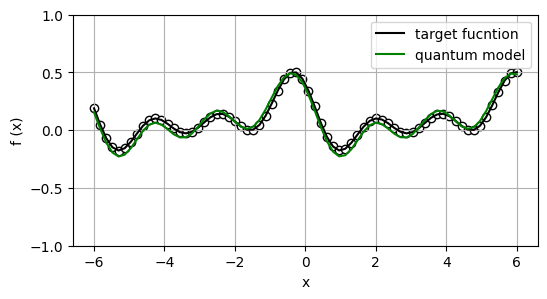

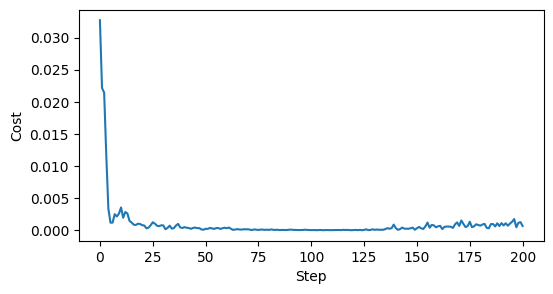

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Ansatz 2

In [ ]:
### setting ansatz ###

ansatz = 2
n_qubits = 2
n_layers = 4
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_2(theta):
    """Trainable circuit block."""
    qcnn_unit9(theta[0],0,1)
    
@qml.qnode(dev)
def quantum_model_2(weights, x):

    for i in range(n_layers):
        W_2(weights[i])
        S(x)
    W_2(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

weights = 2 * np.pi * np.random.random(size=(n_layers+1, 1, 15), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_2, expansion_strategy="device")(weights,x_sample))

0: ──U3(0.23,4.91,0.21)─╭●──RY(5.63)─╭X──RY(1.63)─╭●──U3(3.65,3.71,0.14)──RX(-6.00)
1: ──U3(4.97,1.51,4.29)─╰X──RZ(3.66)─╰●───────────╰X──U3(6.16,3.51,5.52)──RX(-6.00)

───U3(1.11,4.47,3.43)─╭●──RY(3.89)─╭X──RY(2.58)─╭●──U3(1.13,1.91,3.21)──RX(-6.00)
───U3(3.55,2.86,0.77)─╰X──RZ(3.90)─╰●───────────╰X──U3(6.21,0.51,0.16)──RX(-6.00)

───U3(3.90,0.12,3.72)─╭●──RY(0.89)─╭X──RY(3.22)─╭●──U3(3.03,2.66,6.05)──RX(-6.00)
───U3(1.55,0.33,4.68)─╰X──RZ(6.19)─╰●───────────╰X──U3(5.83,4.74,5.53)──RX(-6.00)

───U3(2.99,3.37,4.16)─╭●──RY(0.88)─╭X──RY(2.16)─╭●──U3(2.82,5.52,4.35)──RX(-6.00)
───U3(3.83,4.56,2.31)─╰X──RZ(5.16)─╰●───────────╰X──U3(2.13,1.66,5.87)──RX(-6.00)

───U3(3.62,5.43,3.22)─╭●──RY(1.12)─╭X──RY(0.58)─╭●──U3(0.30,0.15,2.34)─┤  <Z>
───U3(3.32,6.12,5.63)─╰X──RZ(2.79)─╰●───────────╰X──U3(5.83,2.85,3.08)─┤     


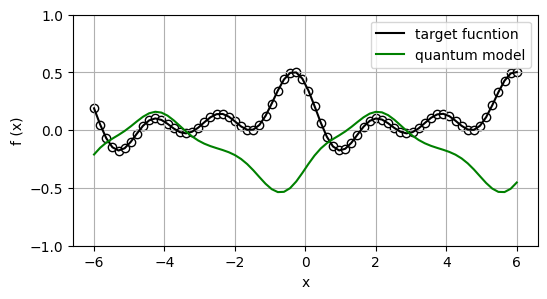

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_2)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.008517544742215201
Cost at step  10: 0.0028135796037437387
Cost at step  15: 0.0026311163290818904
Cost at step  20: 0.001488662991071797
Cost at step  25: 0.000958015906610587
Cost at step  30: 0.001279125387067659
Cost at step  35: 0.0004924747016255194
Cost at step  40: 0.0003728718598703901
Cost at step  45: 0.0011251703037913144
Cost at step  50: 0.0011503949919943117
Cost at step  55: 0.0007852960983659308
Cost at step  60: 0.0004620990176522182
Cost at step  65: 7.339566083207783e-05
Cost at step  70: 8.03966204887226e-05
Cost at step  75: 8.345222267166773e-05
Cost at step  80: 7.954568458369117e-05
Cost at step  85: 0.00010386784578340631
Cost at step  90: 1.9807573318400965e-05
Cost at step  95: 1.0989051860847422e-05
Cost at step 100: 1.192111511437178e-05
Cost at step 105: 1.4878949516739988e-05
Cost at step 110: 5.0698628577597926e-05
Cost at step 115: 2.463351865649765e-05
Cost at step 120: 4.139088773997394e-05
Cost at step 125: 1.6608400050399418e-05

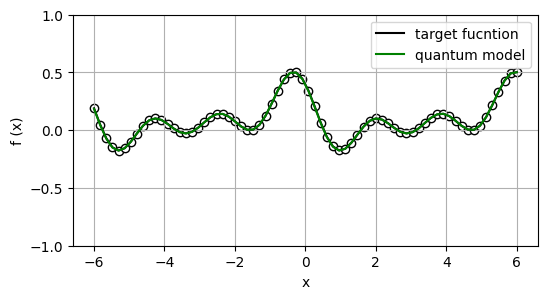

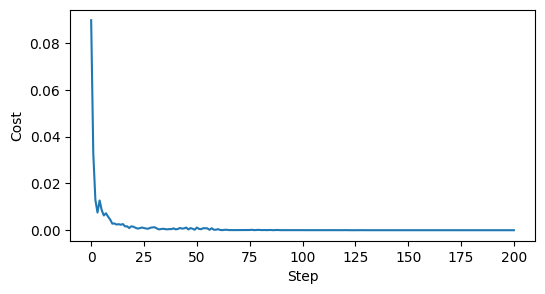

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='green',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Final Plot

In [ ]:
### load weights ###

weights1=np.load('./save/weight_hist_ansatz_1_degree_3_qubits_2_layers_4.npy')[-1]
weights2=np.load('./save/weight_hist_ansatz_2_degree_3_qubits_2_layers_4.npy')[-1]

predictions1 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights1,x_)))) for x_ in x]
predictions2 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights2,x_)))) for x_ in x]

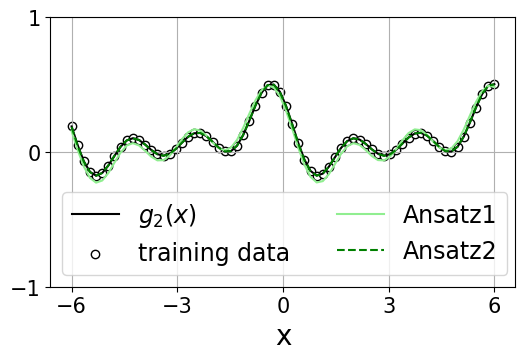

In [ ]:
### final plot ###

plt.figure(figsize=(6,3.5))
plt.xlabel('x',fontsize=20)
plt.yticks([-1,0,1],fontsize=15)
plt.xticks([-6,-3,0,3,6],fontsize=15)
plt.plot(x, target_y, c='black',label=r'$g_2(x)$')
plt.scatter(x, target_y, facecolor='white', edgecolor='black',label='training data')
plt.plot(x, predictions1, c='#90EE90',label='Ansatz1',alpha=1)
plt.plot(x, predictions2, c='#008000',label='Ansatz2',linestyle='--')
plt.ylim(-1,1)
plt.grid()
plt.legend(fontsize=17,ncols=2)
plt.show();

# $g_3(x)=\sum^4_{-4}c_k\exp(ikx)$ (9 modes) 

## target function

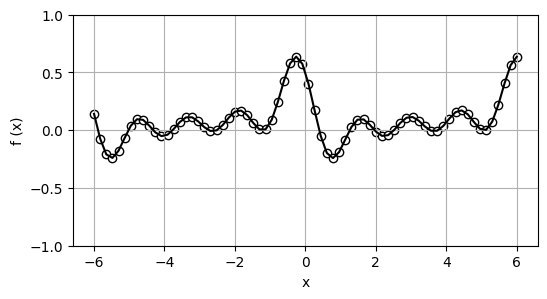

In [ ]:
### target function ###

degree = 4  # degree of the target function
scaling = 1  # scaling of the data
coeffs = [0.05 + 0.05j]*degree  # coefficients of non-zero frequencies
coeff0 = 0.1  # coefficient of zero frequency

def target_function(x):
    """Generate a truncated Fourier series, where the data gets re-scaled."""
    res = coeff0
    for idx, coeff in enumerate(coeffs):
        exponent = np.complex128(scaling * (idx+1) * x * 1j)
        conj_coeff = np.conjugate(coeff)
        res += coeff * np.exp(exponent) + conj_coeff * np.exp(-exponent)
    return np.real(res)

x = np.linspace(-6, 6, 70, requires_grad=False)
target_y = np.array([target_function(x_) for x_ in x], requires_grad=True)

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.ylim(-1, 1)
plt.grid()
plt.show();

## model 1 (2-qubit & 2-layer)
$$
|\Omega_{\text{target function}}|=9>|\Omega_{\text{model 1}}|=5
$$

### Ansatz 1

In [ ]:
### setting ansatz ###

ansatz = 1
n_qubits = 2
n_layers = 2
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_1(theta):
    """Trainable circuit block."""
    StronglyEntanglingLayers(theta, wires=range(n_qubits))

@qml.qnode(dev)
def quantum_model_1(weights, x):

    for i in range(n_layers):
        W_1(weights[i])
        S(x)
    W_1(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

trainable_block_layers = 3
weights = 2 * np.pi * np.random.random(size=(n_layers+1, trainable_block_layers, n_qubits, 3), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_1, expansion_strategy="device")(weights,x_sample))

0: ──Rot(5.89,3.24,2.09)─╭●─╭X──Rot(1.93,1.25,4.81)─╭●─╭X──Rot(0.70,0.58,3.25)─╭●─╭X──RX(-6.00)
1: ──Rot(0.04,0.50,0.69)─╰X─╰●──Rot(3.50,5.61,2.95)─╰X─╰●──Rot(4.91,2.82,3.70)─╰X─╰●──RX(-6.00)

───Rot(4.02,0.67,4.26)─╭●─╭X──Rot(0.61,3.11,6.14)─╭●─╭X──Rot(3.56,0.11,2.90)─╭●─╭X──RX(-6.00)
───Rot(5.83,4.08,4.17)─╰X─╰●──Rot(3.20,5.58,1.13)─╰X─╰●──Rot(1.71,1.72,1.62)─╰X─╰●──RX(-6.00)

───Rot(4.07,2.86,0.73)─╭●─╭X──Rot(4.12,4.21,5.61)─╭●─╭X──Rot(4.23,4.17,0.24)─╭●─╭X─┤  <Z>
───Rot(4.95,0.34,1.36)─╰X─╰●──Rot(6.04,6.15,1.16)─╰X─╰●──Rot(5.28,4.88,2.75)─╰X─╰●─┤     


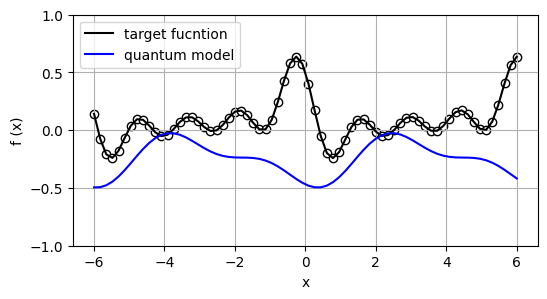

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_1)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.017451853373381176
Cost at step  10: 0.012174438884882477
Cost at step  15: 0.0127222167516226
Cost at step  20: 0.01190421113835242
Cost at step  25: 0.0105684812282282
Cost at step  30: 0.010330052124272003
Cost at step  35: 0.010834239479899917
Cost at step  40: 0.010630543402235926
Cost at step  45: 0.010206763986054692
Cost at step  50: 0.011067051470679512
Cost at step  55: 0.01324845681188205
Cost at step  60: 0.009992335013354697
Cost at step  65: 0.010281254295333081
Cost at step  70: 0.010444597821034365
Cost at step  75: 0.010436855635369847
Cost at step  80: 0.014663350089728211
Cost at step  85: 0.010636837633279241
Cost at step  90: 0.013331967097242147
Cost at step  95: 0.013947363214911062
Cost at step 100: 0.012600752727581202
Cost at step 105: 0.013278019654881254
Cost at step 110: 0.010780933467885943
Cost at step 115: 0.010338889293116561
Cost at step 120: 0.011473041343443522
Cost at step 125: 0.012915796618278828
Cost at step 130: 0.01113118110

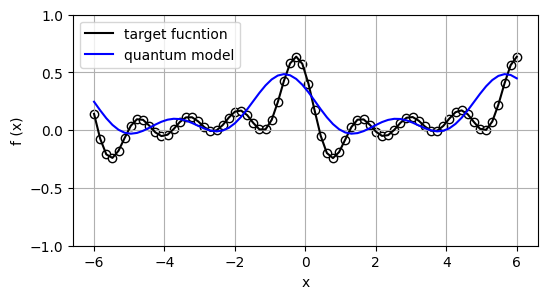

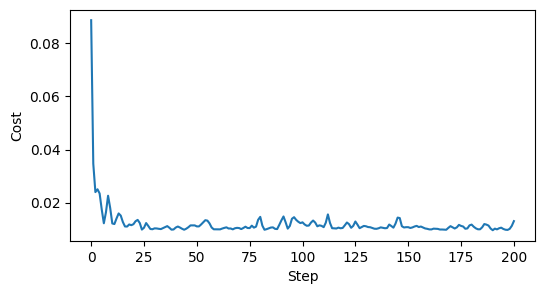

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Ansatz 2

In [ ]:
### setting ansatz ###

ansatz = 2
n_qubits = 2
n_layers = 2
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_2(theta):
    """Trainable circuit block."""
    qcnn_unit9(theta[0],0,1)

@qml.qnode(dev)
def quantum_model_2(weights, x):

    for i in range(n_layers):
        W_2(weights[i])
        S(x)
    W_2(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

weights = 2 * np.pi * np.random.random(size=(n_layers+1, 1, 15), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_2, expansion_strategy="device")(weights,x_sample))

0: ──U3(1.31,4.57,0.05)─╭●──RY(2.50)─╭X──RY(1.42)─╭●──U3(1.67,4.79,4.43)──RX(-6.00)
1: ──U3(5.01,0.79,5.15)─╰X──RZ(0.73)─╰●───────────╰X──U3(1.24,4.82,4.22)──RX(-6.00)

───U3(0.82,2.32,0.33)─╭●──RY(1.62)─╭X──RY(0.55)─╭●──U3(3.73,4.82,4.15)──RX(-6.00)
───U3(1.55,0.70,6.17)─╰X──RZ(3.60)─╰●───────────╰X──U3(3.49,1.79,2.90)──RX(-6.00)

───U3(0.77,4.32,3.91)─╭●──RY(3.41)─╭X──RY(0.30)─╭●──U3(1.18,5.26,3.67)─┤  <Z>
───U3(5.14,2.52,0.09)─╰X──RZ(3.37)─╰●───────────╰X──U3(3.63,0.12,2.87)─┤     


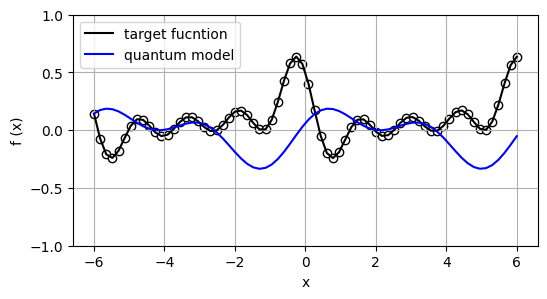

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_2)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

/opt/homebrew/Caskroom/miniforge/base/envs/newdqc/lib/python3.9/site-packages/autograd/numpy/numpy_vjps.py:698: ComplexWarning: Casting complex values to real discards the imaginary part
  onp.add.at(A, idx, x)


Cost at step   5: 0.011059010804890062
Cost at step  10: 0.016131106647999254
Cost at step  15: 0.012364799482816274
Cost at step  20: 0.011658257370044283
Cost at step  25: 0.010918170285935648
Cost at step  30: 0.010783945496308628
Cost at step  35: 0.010830444754348233
Cost at step  40: 0.011362204108441623
Cost at step  45: 0.010859111273129326
Cost at step  50: 0.011207997509430731
Cost at step  55: 0.011024648442645777
Cost at step  60: 0.011855026070841067
Cost at step  65: 0.010510157222718594
Cost at step  70: 0.011450721180479993
Cost at step  75: 0.009943746302796132
Cost at step  80: 0.011694093895826414
Cost at step  85: 0.01329231667804423
Cost at step  90: 0.012395897044429024
Cost at step  95: 0.012070945346194002
Cost at step 100: 0.01277146573547828
Cost at step 105: 0.011407586894418374
Cost at step 110: 0.014662747854705697
Cost at step 115: 0.011055509421412554
Cost at step 120: 0.010814401960218734
Cost at step 125: 0.012944928187524607
Cost at step 130: 0.0136170

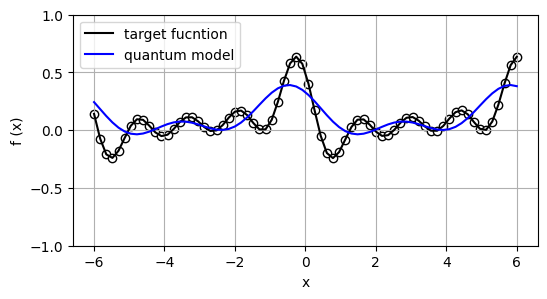

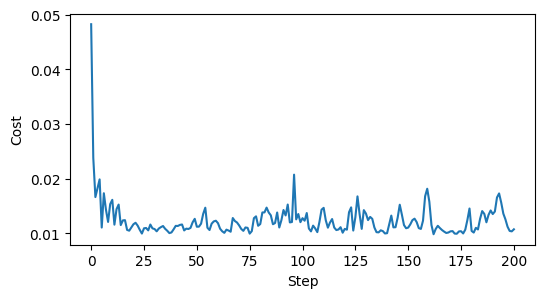

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Final Plot

In [ ]:
### load weights ###

weights1=np.load('./save/weight_hist_ansatz_1_degree_4_qubits_2_layers_2.npy')[-1]
weights2=np.load('./save/weight_hist_ansatz_2_degree_4_qubits_2_layers_2.npy')[-1]

predictions1 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights1,x_)))) for x_ in x]
predictions2 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights2,x_)))) for x_ in x]

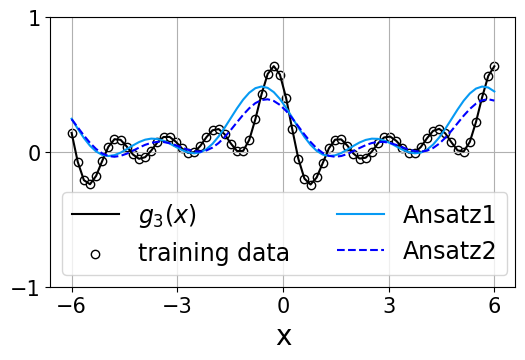

In [ ]:
### final plot ###

plt.figure(figsize=(6,3.5))
plt.xlabel('x',fontsize=20)
plt.yticks([-1,0,1],fontsize=15)
plt.xticks([-6,-3,0,3,6],fontsize=15)
plt.plot(x, target_y, c='black',label=r'$g_3(x)$')
plt.scatter(x, target_y, facecolor='white', edgecolor='black',label='training data')
plt.plot(x, predictions1, c='#069AF3',label='Ansatz1',alpha=1)
plt.plot(x, predictions2, c='#0000ff',label='Ansatz2',alpha=1,linestyle='--')
plt.ylim(-1,1)
plt.grid()
plt.legend(fontsize=17,ncols=2)
plt.show();

## model 2 (3-qubit & 2-layer)
$$
|\Omega_{\text{target function}}|=9>|\Omega_{\text{model 2}}|=7
$$

### Ansatz 1

In [ ]:
### setting ansatz ###

ansatz = 1
n_qubits = 3
n_layers = 2
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_1(theta):
    """Trainable circuit block."""
    StronglyEntanglingLayers(theta, wires=range(n_qubits))

@qml.qnode(dev)
def quantum_model_1(weights, x):

    for i in range(n_layers):
        W_1(weights[i])
        S(x)
    W_1(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

trainable_block_layers = 3
weights = 2 * np.pi * np.random.random(size=(n_layers+1, trainable_block_layers, n_qubits, 3), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_1, expansion_strategy="device")(weights,x_sample))

0: ──Rot(2.34,1.29,4.00)─╭●────╭X──Rot(4.39,5.55,2.06)─╭●─╭X──Rot(3.12,6.01,5.88)
1: ──Rot(1.66,2.61,1.11)─╰X─╭●─│───Rot(5.40,5.04,6.01)─│──╰●─╭X──────────────────
2: ──Rot(5.62,1.60,2.01)────╰X─╰●──Rot(0.34,3.29,5.92)─╰X────╰●──────────────────

───────────────────────╭●────╭X──RX(-6.00)──Rot(3.92,5.42,5.62)─╭●────╭X──Rot(2.24,1.74,2.12)─╭●─╭X
───Rot(3.09,0.78,4.02)─╰X─╭●─│───RX(-6.00)──Rot(1.30,2.98,0.87)─╰X─╭●─│───Rot(1.18,3.22,0.27)─│──╰●
───Rot(4.45,3.49,0.95)────╰X─╰●──RX(-6.00)──Rot(0.34,2.07,2.67)────╰X─╰●──Rot(4.96,3.11,2.54)─╰X───

───Rot(4.72,3.35,3.02)──────────────────────╭●────╭X──RX(-6.00)──Rot(0.66,1.56,1.17)─╭●────╭X
──╭X────────────────────Rot(3.42,0.82,4.22)─╰X─╭●─│───RX(-6.00)──Rot(2.49,4.08,2.22)─╰X─╭●─│─
──╰●────────────────────Rot(4.67,1.62,5.72)────╰X─╰●──RX(-6.00)──Rot(0.14,5.21,0.54)────╰X─╰●

───Rot(5.81,2.20,4.04)─╭●─╭X──Rot(5.81,5.14,0.60)──────────────────────╭●────╭X─┤  <Z>
───Rot(5.36,1.42,2.40)─│──╰●─╭X────────────────────Rot(6.26,6.28,2.60)─╰X─╭●─│──┤ 

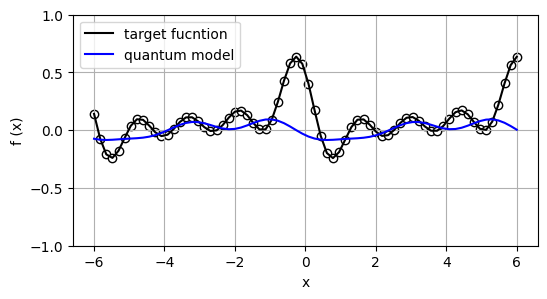

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_1)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.011272438456177243
Cost at step  10: 0.007452810878055987
Cost at step  15: 0.007384934421321822
Cost at step  20: 0.007088645120426562
Cost at step  25: 0.00862560708764823
Cost at step  30: 0.006698616427873148
Cost at step  35: 0.00822216710053524
Cost at step  40: 0.006667201709460106
Cost at step  45: 0.007115163953087976
Cost at step  50: 0.006734905806836748
Cost at step  55: 0.006148421661897369
Cost at step  60: 0.006138993881510505
Cost at step  65: 0.00548422294422629
Cost at step  70: 0.0059292647083178
Cost at step  75: 0.005912698865854533
Cost at step  80: 0.005882604301544183
Cost at step  85: 0.0059667252514957365
Cost at step  90: 0.005946996531594986
Cost at step  95: 0.005625993241777101
Cost at step 100: 0.00864673183458545
Cost at step 105: 0.006425253337948202
Cost at step 110: 0.007077825978776903
Cost at step 115: 0.006215781304886791
Cost at step 120: 0.00625070576773009
Cost at step 125: 0.006965603476781285
Cost at step 130: 0.00577733293

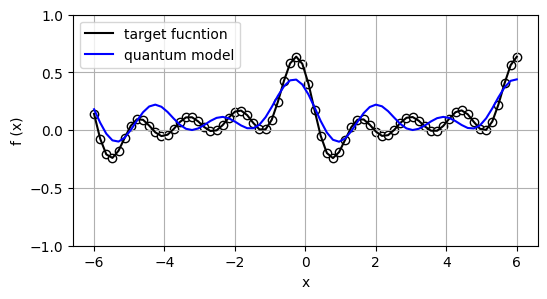

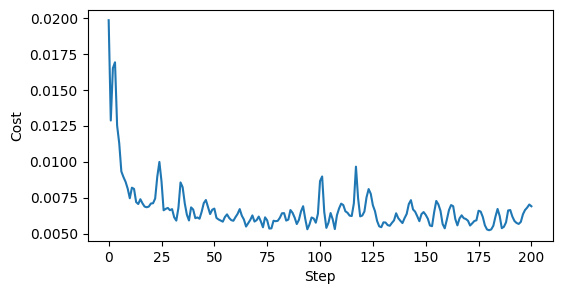

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Ansatz 2

In [ ]:
### setting ansatz ###

ansatz = 2
n_qubits = 3
n_layers = 2
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_2(theta):
    """Trainable circuit block."""
    qcnn_unit9(theta[0],0,1)
    qcnn_unit9(theta[1],1,2)
    
@qml.qnode(dev)
def quantum_model_2(weights, x):

    for i in range(n_layers):
        W_2(weights[i])
        S(x)
    W_2(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

weights = 2 * np.pi * np.random.random(size=(n_layers+1, 2,15), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_2, expansion_strategy="device")(weights,x_sample))

0: ──U3(2.13,5.93,6.02)─╭●──RY(4.16)─╭X──RY(2.18)─╭●──U3(1.32,6.14,4.91)──RX(-6.00)─────────
1: ──U3(3.22,2.97,1.68)─╰X──RZ(5.66)─╰●───────────╰X──U3(0.71,3.95,4.26)──U3(0.59,2.40,4.50)
2: ──U3(3.28,2.73,0.74)─────────────────────────────────────────────────────────────────────

───U3(4.42,0.89,1.30)─────────────────────────────────────────────────────────────────────────────
──╭●───────────────────RY(1.80)─╭X──RY(5.64)─╭●──U3(2.32,6.17,0.43)──RX(-6.00)──U3(0.47,3.74,3.03)
──╰X───────────────────RZ(4.45)─╰●───────────╰X──U3(3.47,5.68,2.54)──RX(-6.00)──U3(2.56,0.52,6.17)

──╭●──RY(0.02)─╭X──RY(5.33)─╭●──U3(3.53,6.00,2.32)──RX(-6.00)───────────U3(2.08,5.65,0.46)──────────
──╰X──RZ(1.75)─╰●───────────╰X──U3(0.43,0.74,3.66)──U3(2.40,0.56,2.60)─╭●───────────────────RY(5.85)
───────────────────────────────────────────────────────────────────────╰X───────────────────RZ(2.70)

─────────────────────────────────────────────────────────────────────╭●──RY(2.31)─╭X──RY(6.24)─╭●
──╭X──RY(4.94)─╭●──U

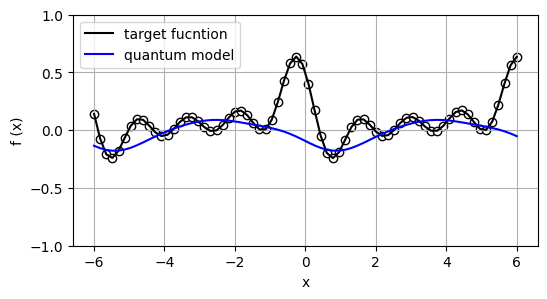

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_2)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.010381787838460051
Cost at step  10: 0.008914419447898506
Cost at step  15: 0.007410506546868759
Cost at step  20: 0.007533015373130386
Cost at step  25: 0.00811073363292608
Cost at step  30: 0.010435315451318702
Cost at step  35: 0.0064694912772086804
Cost at step  40: 0.006369027090927755
Cost at step  45: 0.006898034096948903
Cost at step  50: 0.006578158053720712
Cost at step  55: 0.009005716473157892
Cost at step  60: 0.008147737784447237
Cost at step  65: 0.0196664846472908
Cost at step  70: 0.006243499849864428
Cost at step  75: 0.02630440344784984
Cost at step  80: 0.01668713926804225
Cost at step  85: 0.008747797044869486
Cost at step  90: 0.007191312787365027
Cost at step  95: 0.0062790959720527735
Cost at step 100: 0.006102497008315329
Cost at step 105: 0.005663799130447418
Cost at step 110: 0.006208784133056301
Cost at step 115: 0.005273765916830657
Cost at step 120: 0.006020520800101426
Cost at step 125: 0.009151630817029332
Cost at step 130: 0.00624196

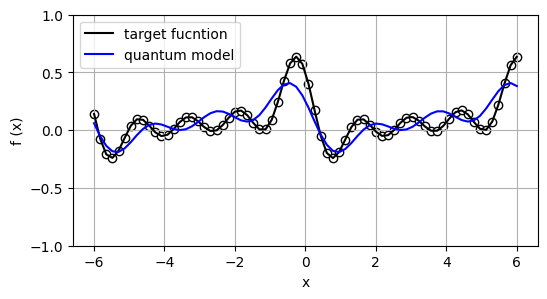

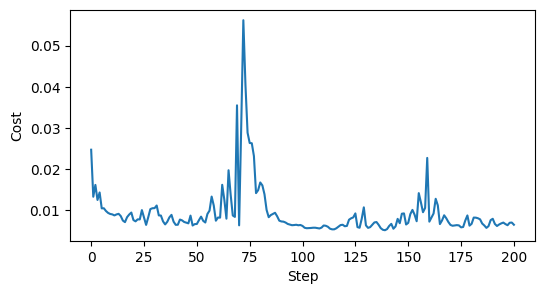

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Final Plot

In [ ]:
### load weights ###

weights1=np.load('./save/weight_hist_ansatz_1_degree_4_qubits_3_layers_2.npy')[-1]
weights2=np.load('./save/weight_hist_ansatz_2_degree_4_qubits_3_layers_2.npy')[-1]

predictions1 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights1,x_)))) for x_ in x]
predictions2 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights2,x_)))) for x_ in x]

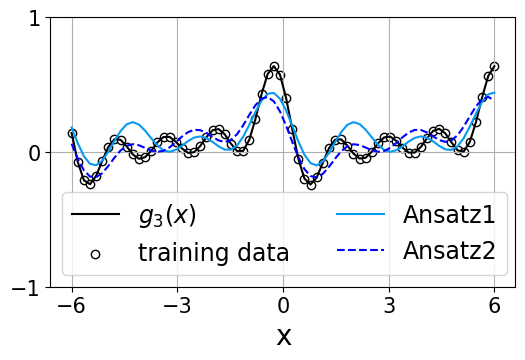

In [ ]:
### final plot ###

plt.figure(figsize=(6,3.5))
plt.xlabel('x',fontsize=20)
plt.yticks([-1,0,1],fontsize=15)
plt.xticks([-6,-3,0,3,6],fontsize=15)
plt.plot(x, target_y, c='black',label=r'$g_3(x)$')
plt.scatter(x, target_y, facecolor='white', edgecolor='black',label='training data')
plt.plot(x, predictions1, c='#069AF3',label='Ansatz1',alpha=1)
plt.plot(x, predictions2, c='#0000ff',label='Ansatz2',alpha=1,linestyle='--')
plt.ylim(-1,1)
plt.grid()
plt.legend(fontsize=17,ncols=2)
plt.show();

## model 3 (2-qubit & 3-layer)
$$
|\Omega_{\text{target function}}|=9>|\Omega_{\text{model 3}}|=7
$$

### Ansatz 1

In [ ]:
### setting ansatz ###

ansatz = 1
n_qubits = 2
n_layers = 3
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_1(theta):
    """Trainable circuit block."""
    StronglyEntanglingLayers(theta, wires=range(n_qubits))

@qml.qnode(dev)
def quantum_model_1(weights, x):

    for i in range(n_layers):
        W_1(weights[i])
        S(x)
    W_1(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

trainable_block_layers = 3
weights = 2 * np.pi * np.random.random(size=(n_layers+1, trainable_block_layers, n_qubits, 3), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_1, expansion_strategy="device")(weights,x_sample))

0: ──Rot(6.15,2.12,0.86)─╭●─╭X──Rot(3.10,4.87,3.97)─╭●─╭X──Rot(0.34,0.07,4.62)─╭●─╭X──RX(-6.00)
1: ──Rot(3.82,1.65,3.41)─╰X─╰●──Rot(5.45,2.47,2.16)─╰X─╰●──Rot(5.82,0.60,5.69)─╰X─╰●──RX(-6.00)

───Rot(4.41,4.87,4.68)─╭●─╭X──Rot(2.16,3.21,5.55)─╭●─╭X──Rot(5.88,0.52,2.41)─╭●─╭X──RX(-6.00)
───Rot(4.66,4.57,5.41)─╰X─╰●──Rot(3.91,1.53,1.21)─╰X─╰●──Rot(0.82,5.36,5.44)─╰X─╰●──RX(-6.00)

───Rot(4.71,6.24,5.49)─╭●─╭X──Rot(5.21,2.36,4.32)─╭●─╭X──Rot(0.27,1.49,3.16)─╭●─╭X──RX(-6.00)
───Rot(1.41,4.11,4.88)─╰X─╰●──Rot(5.66,5.77,2.30)─╰X─╰●──Rot(5.57,1.67,3.46)─╰X─╰●──RX(-6.00)

───Rot(4.35,5.37,4.03)─╭●─╭X──Rot(1.94,0.58,5.54)─╭●─╭X──Rot(2.41,5.69,4.74)─╭●─╭X─┤  <Z>
───Rot(3.31,1.13,2.61)─╰X─╰●──Rot(5.56,1.09,4.75)─╰X─╰●──Rot(0.08,5.76,5.99)─╰X─╰●─┤     


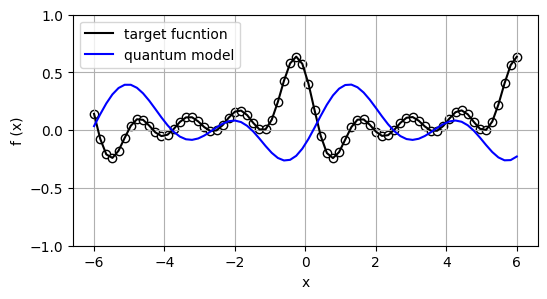

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_1)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.015245118757738707
Cost at step  10: 0.008358010062922123
Cost at step  15: 0.010622459752452608
Cost at step  20: 0.006255507874116004
Cost at step  25: 0.005955885020561322
Cost at step  30: 0.005509633279355326
Cost at step  35: 0.006399566542609649
Cost at step  40: 0.005785139289769545
Cost at step  45: 0.007566651087931645
Cost at step  50: 0.007606949719230316
Cost at step  55: 0.006006556584188593
Cost at step  60: 0.006285497113653888
Cost at step  65: 0.006466861388837843
Cost at step  70: 0.011703172602528521
Cost at step  75: 0.011934046064939504
Cost at step  80: 0.008147744663343434
Cost at step  85: 0.009662778845640901
Cost at step  90: 0.006535486768545451
Cost at step  95: 0.011360370005064986
Cost at step 100: 0.011830716056776727
Cost at step 105: 0.009398054208335976
Cost at step 110: 0.007591139452867988
Cost at step 115: 0.005663109280459644
Cost at step 120: 0.0054241304886901084
Cost at step 125: 0.0058451924042987645
Cost at step 130: 0.006

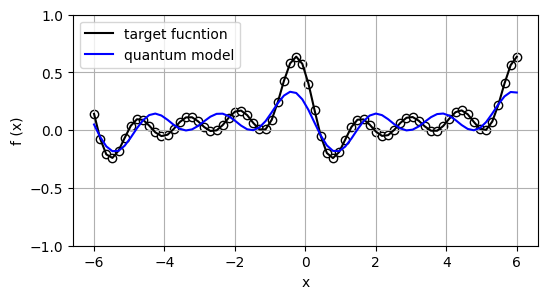

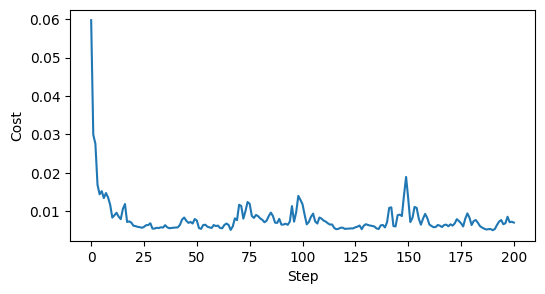

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Ansatz 2

In [ ]:
### setting ansatz ###

ansatz = 2
n_qubits = 2
n_layers = 3
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_2(theta):
    """Trainable circuit block."""
    qcnn_unit9(theta[0],0,1)
    
@qml.qnode(dev)
def quantum_model_2(weights, x):

    for i in range(n_layers):
        W_2(weights[i])
        S(x)
    W_2(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

weights = 2 * np.pi * np.random.random(size=(n_layers+1, 1, 15), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_2, expansion_strategy="device")(weights,x_sample))

0: ──U3(3.97,4.94,3.53)─╭●──RY(4.42)─╭X──RY(3.11)─╭●──U3(1.74,6.26,0.17)──RX(-6.00)
1: ──U3(3.37,4.96,5.43)─╰X──RZ(4.81)─╰●───────────╰X──U3(3.15,2.77,0.61)──RX(-6.00)

───U3(5.69,0.28,3.54)─╭●──RY(1.55)─╭X──RY(1.92)─╭●──U3(5.27,1.68,5.16)──RX(-6.00)
───U3(3.76,5.19,0.09)─╰X──RZ(1.93)─╰●───────────╰X──U3(3.03,5.42,3.89)──RX(-6.00)

───U3(5.87,0.19,0.59)─╭●──RY(5.13)─╭X──RY(3.01)─╭●──U3(2.03,5.10,2.87)──RX(-6.00)
───U3(3.13,2.74,0.95)─╰X──RZ(1.89)─╰●───────────╰X──U3(1.43,0.97,2.31)──RX(-6.00)

───U3(5.45,0.19,3.91)─╭●──RY(5.72)─╭X──RY(6.14)─╭●──U3(2.09,0.44,1.81)─┤  <Z>
───U3(5.77,2.04,4.93)─╰X──RZ(4.09)─╰●───────────╰X──U3(5.74,1.37,0.34)─┤     


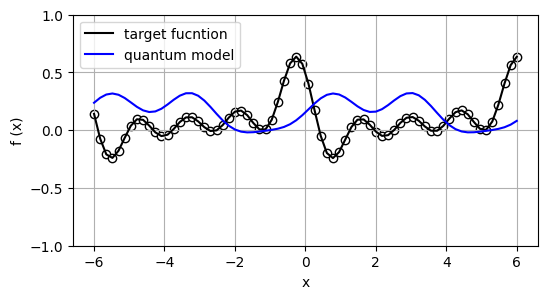

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_2)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.02775734091959775
Cost at step  10: 0.012430993832707219
Cost at step  15: 0.011301564016285513
Cost at step  20: 0.009759938129766105
Cost at step  25: 0.009290114712360001
Cost at step  30: 0.007128113286344045
Cost at step  35: 0.007283117420573761
Cost at step  40: 0.005848080036363134
Cost at step  45: 0.006304223114834797
Cost at step  50: 0.005396204477087558
Cost at step  55: 0.006359888270891239
Cost at step  60: 0.005639989557401717
Cost at step  65: 0.006425168172943211
Cost at step  70: 0.006888397910127455
Cost at step  75: 0.0061064970416127295
Cost at step  80: 0.006331262747412031
Cost at step  85: 0.00722675339289124
Cost at step  90: 0.006023239423597281
Cost at step  95: 0.005568653263134926
Cost at step 100: 0.005449827955489794
Cost at step 105: 0.006068847630911357
Cost at step 110: 0.00735283237777901
Cost at step 115: 0.005476348408270554
Cost at step 120: 0.006306993049237731
Cost at step 125: 0.005395272077991759
Cost at step 130: 0.0073628

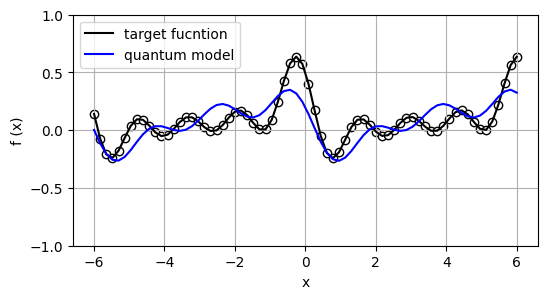

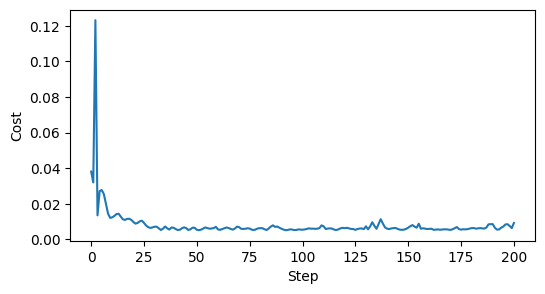

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Final Plot

In [ ]:
### load weights ###

weights1=np.load('./save/weight_hist_ansatz_1_degree_4_qubits_2_layers_3.npy')[-1]
weights2=np.load('./save/weight_hist_ansatz_2_degree_4_qubits_2_layers_3.npy')[-1]

predictions1 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights1,x_)))) for x_ in x]
predictions2 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights2,x_)))) for x_ in x]

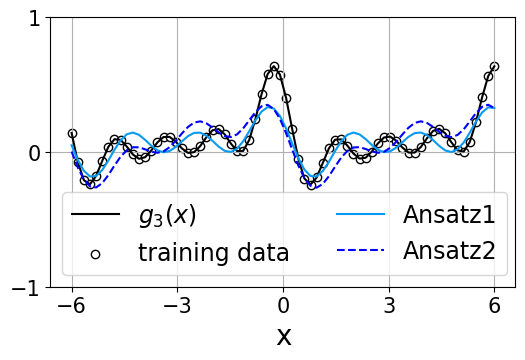

In [ ]:
### final plot ###

plt.figure(figsize=(6,3.5))
plt.xlabel('x',fontsize=20)
plt.yticks([-1,0,1],fontsize=15)
plt.xticks([-6,-3,0,3,6],fontsize=15)
plt.plot(x, target_y, c='black',label=r'$g_3(x)$')
plt.scatter(x, target_y, facecolor='white', edgecolor='black',label='training data')
plt.plot(x, predictions1, c='#069AF3',label='Ansatz1',alpha=1)
plt.plot(x, predictions2, c='#0000ff',label='Ansatz2',alpha=1,linestyle='--')
plt.ylim(-1,1)
plt.grid()
plt.legend(fontsize=17,ncols=2)
plt.show();

## model 4 (4-qubit & 2-layer)
$$
|\Omega_{\text{target function}}|=9=|\Omega_{\text{model 4}}|
$$

### Ansatz 1

In [ ]:
### setting ansatz ###

ansatz = 1
n_qubits = 4
n_layers = 2
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_1(theta):
    """Trainable circuit block."""
    StronglyEntanglingLayers(theta, wires=range(n_qubits))

@qml.qnode(dev)
def quantum_model_1(weights, x):

    for i in range(n_layers):
        W_1(weights[i])
        S(x)
    W_1(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

trainable_block_layers = 3
weights = 2 * np.pi * np.random.random(size=(n_layers+1, trainable_block_layers, n_qubits, 3), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_1, expansion_strategy="device")(weights,x_sample))

0: ──Rot(2.68,3.55,5.33)─╭●───────╭X──Rot(5.29,2.79,3.47)─╭●────╭X──Rot(5.94,4.37,0.20)
1: ──Rot(4.37,1.90,1.66)─╰X─╭●────│───Rot(0.85,0.62,5.04)─│──╭●─│──╭X──────────────────
2: ──Rot(5.83,6.12,6.24)────╰X─╭●─│───Rot(1.02,0.60,2.29)─╰X─│──╰●─│───────────────────
3: ──Rot(1.21,4.85,1.01)───────╰X─╰●──Rot(1.85,5.98,4.45)────╰X────╰●──────────────────

───────────────────────╭●─╭X──RX(-6.00)──Rot(2.78,4.45,6.05)─────────────────────
───Rot(3.04,4.92,3.76)─│──╰●─╭X──────────RX(-6.00)────────────Rot(3.82,3.60,0.40)
───Rot(3.37,5.86,1.79)─│─────╰●─────────╭X────────────────────RX(-6.00)──────────
───Rot(3.99,1.97,4.13)─╰X───────────────╰●────────────────────RX(-6.00)──────────

──╭●─────────────────────────╭X──Rot(2.41,2.28,2.58)─╭●────╭X──Rot(4.89,3.44,4.65)
──╰X───────────────────╭●────│───Rot(5.73,0.06,5.51)─│──╭●─│──╭X──────────────────
───Rot(1.87,0.83,5.28)─╰X─╭●─│───Rot(2.30,2.77,4.94)─╰X─│──╰●─│───────────────────
───Rot(0.59,0.94,4.28)────╰X─╰●──Rot(1.62,1.88,0.68)────╰X────╰●─────

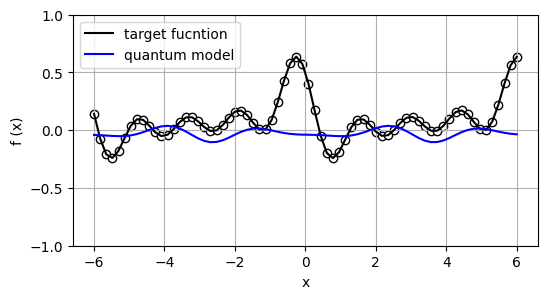

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_1)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.012189528453785134
Cost at step  10: 0.008825121538570919
Cost at step  15: 0.008855886953593215
Cost at step  20: 0.006970529019707549
Cost at step  25: 0.0069104821151058145
Cost at step  30: 0.006126974977623505
Cost at step  35: 0.005303256853283862
Cost at step  40: 0.005486679627677642
Cost at step  45: 0.005314109532660912
Cost at step  50: 0.004603796790934061
Cost at step  55: 0.004538073014823752
Cost at step  60: 0.0041022008526120785
Cost at step  65: 0.004047570379701202
Cost at step  70: 0.0035150732956773273
Cost at step  75: 0.0038695168473682913
Cost at step  80: 0.003963616495069291
Cost at step  85: 0.00355376052921175
Cost at step  90: 0.0029853963251055067
Cost at step  95: 0.002946552746433071
Cost at step 100: 0.0032498010383008617
Cost at step 105: 0.002616247912550755
Cost at step 110: 0.0027288125426892444
Cost at step 115: 0.0022001755973628913
Cost at step 120: 0.002571823493842302
Cost at step 125: 0.002091623196154042
Cost at step 130: 

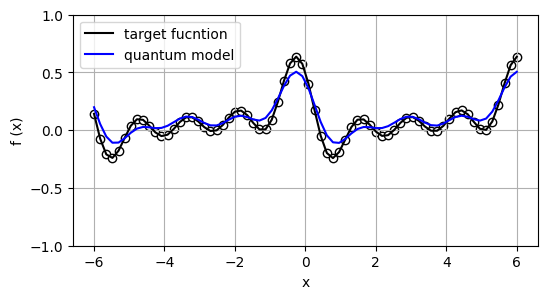

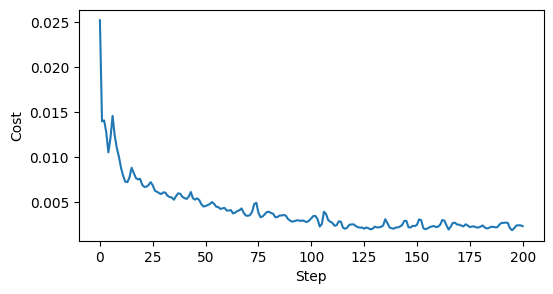

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Ansatz 2

In [ ]:
### setting ansatz ###

ansatz = 2
n_qubits = 4
n_layers = 2
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_2(theta):
    """Trainable circuit block."""
    qcnn_unit9(theta[0],0,1)
    qcnn_unit9(theta[1],2,3)
    qcnn_unit9(theta[2],1,2)
    qcnn_unit9(theta[3],3,0)
    
@qml.qnode(dev)
def quantum_model_2(weights, x):

    for i in range(n_layers):
        W_2(weights[i])
        S(x)
    W_2(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

weights = 2 * np.pi * np.random.random(size=(n_layers+1, 4, 15), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_2, expansion_strategy="device")(weights,x_sample))

0: ──U3(0.78,0.52,4.36)─╭●──RY(0.13)─╭X──RY(1.90)─╭●──U3(4.32,2.43,3.47)──U3(6.25,1.67,4.56)───
1: ──U3(2.52,2.25,3.24)─╰X──RZ(5.36)─╰●───────────╰X──U3(2.60,5.98,3.29)──U3(1.88,0.13,2.24)─╭●
2: ──U3(5.48,3.38,2.64)─╭●──RY(2.00)─╭X──RY(0.70)─╭●──U3(5.27,0.14,4.60)──U3(2.82,0.03,4.86)─╰X
3: ──U3(1.52,1.75,5.46)─╰X──RZ(0.61)─╰●───────────╰X──U3(3.13,0.24,3.23)──U3(1.28,3.48,4.54)───

────────────────────────────────────────────────╭X──RZ(0.35)─╭●───────────╭X──U3(2.54,2.99,2.06)
───RY(5.69)─╭X──RY(2.19)─╭●──U3(0.78,1.36,4.94)─│────────────│────────────│───RX(-6.00)─────────
───RZ(4.64)─╰●───────────╰X──U3(4.18,5.18,3.96)─│────────────│────────────│───RX(-6.00)─────────
────────────────────────────────────────────────╰●──RY(5.05)─╰X──RY(1.57)─╰●──U3(3.98,6.08,3.66)

───RX(-6.00)───────────U3(4.62,0.79,4.19)─╭●──RY(6.11)─╭X──RY(5.90)─╭●──U3(1.59,2.74,5.01)
───U3(5.68,1.83,3.63)─────────────────────╰X──RZ(6.08)─╰●───────────╰X──U3(1.57,4.02,3.27)
───U3(2.12,5.81,4.89)─────────────────────╭●

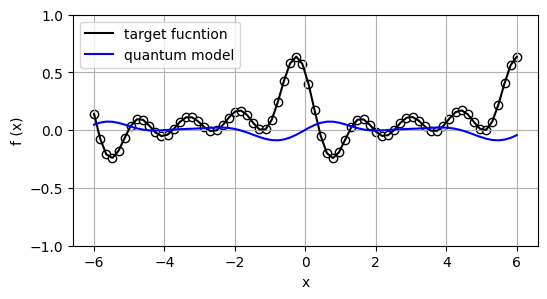

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_2)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.022406386267702447
Cost at step  10: 0.023730353275106978
Cost at step  15: 0.028413643381086973
Cost at step  20: 0.021631198402751697
Cost at step  25: 0.026172394946129125
Cost at step  30: 0.02709722286489952
Cost at step  35: 0.018814612854555008
Cost at step  40: 0.009653786472941702
Cost at step  45: 0.007678976758862288
Cost at step  50: 0.014521628253664622
Cost at step  55: 0.01564682018095299
Cost at step  60: 0.014209996624061519
Cost at step  65: 0.0067453449531903594
Cost at step  70: 0.005606789319561537
Cost at step  75: 0.004969812006473709
Cost at step  80: 0.004279602211673501
Cost at step  85: 0.00357939701375733
Cost at step  90: 0.00314523149100819
Cost at step  95: 0.003484383684246883
Cost at step 100: 0.00510868113923383
Cost at step 105: 0.0057997449294114635
Cost at step 110: 0.007111492818940575
Cost at step 115: 0.021767135129428725
Cost at step 120: 0.006922143344717777
Cost at step 125: 0.007632651525685608
Cost at step 130: 0.00746860

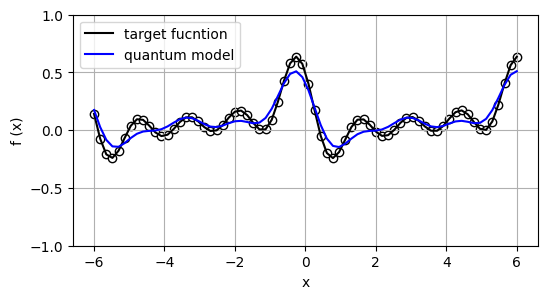

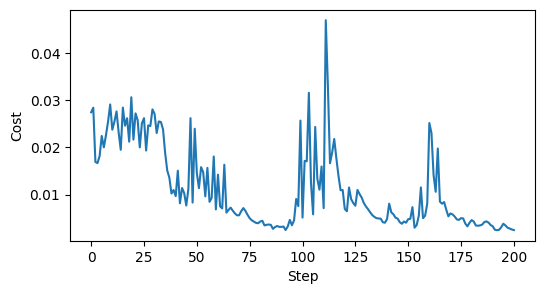

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Final Plot

In [ ]:
### load weights ###

weights1=np.load('./save/weight_hist_ansatz_1_degree_4_qubits_4_layers_2.npy')[-1]
weights2=np.load('./save/weight_hist_ansatz_2_degree_4_qubits_4_layers_2.npy')[-1]

predictions1 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights1,x_)))) for x_ in x]
predictions2 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights2,x_)))) for x_ in x]

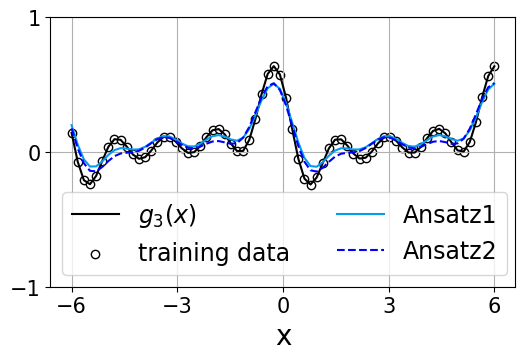

In [ ]:
### final plot ###

plt.figure(figsize=(6,3.5))
plt.xlabel('x',fontsize=20)
plt.yticks([-1,0,1],fontsize=15)
plt.xticks([-6,-3,0,3,6],fontsize=15)
plt.plot(x, target_y, c='black',label=r'$g_3(x)$')
plt.scatter(x, target_y, facecolor='white', edgecolor='black',label='training data')
plt.plot(x, predictions1, c='#069AF3',label='Ansatz1',alpha=1)
plt.plot(x, predictions2, c='#0000ff',label='Ansatz2',alpha=1,linestyle='--')
plt.ylim(-1,1)
plt.grid()
plt.legend(fontsize=17,ncols=2)
plt.show();

## model 5 (2-qubit & 4-layer)
$$
|\Omega_{\text{target function}}|=9=|\Omega_{\text{model 5}}|
$$

### Ansatz 1

In [ ]:
### setting ansatz ###

ansatz = 1
n_qubits = 2
n_layers = 4
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_1(theta):
    """Trainable circuit block."""
    StronglyEntanglingLayers(theta, wires=range(n_qubits))

@qml.qnode(dev)
def quantum_model_1(weights, x):

    for i in range(n_layers):
        W_1(weights[i])
        S(x)
    W_1(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

trainable_block_layers = 3
weights = 2 * np.pi * np.random.random(size=(n_layers+1, trainable_block_layers, n_qubits, 3), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_1, expansion_strategy="device")(weights,x_sample))

0: ──Rot(2.09,0.22,2.78)─╭●─╭X──Rot(2.18,2.74,1.06)─╭●─╭X──Rot(5.34,1.07,5.70)─╭●─╭X──RX(-6.00)
1: ──Rot(1.41,3.94,0.67)─╰X─╰●──Rot(1.54,2.76,1.28)─╰X─╰●──Rot(3.19,0.12,4.98)─╰X─╰●──RX(-6.00)

───Rot(5.46,3.11,4.33)─╭●─╭X──Rot(4.94,4.12,0.09)─╭●─╭X──Rot(4.61,4.67,3.44)─╭●─╭X──RX(-6.00)
───Rot(0.38,3.51,4.54)─╰X─╰●──Rot(2.16,2.32,6.01)─╰X─╰●──Rot(4.87,1.82,1.04)─╰X─╰●──RX(-6.00)

───Rot(1.61,3.10,0.14)─╭●─╭X──Rot(5.64,4.41,1.73)─╭●─╭X──Rot(4.89,5.69,1.96)─╭●─╭X──RX(-6.00)
───Rot(1.54,2.61,2.71)─╰X─╰●──Rot(2.07,2.27,0.53)─╰X─╰●──Rot(5.69,4.94,4.81)─╰X─╰●──RX(-6.00)

───Rot(3.00,3.63,2.45)─╭●─╭X──Rot(5.02,1.51,1.98)─╭●─╭X──Rot(2.16,2.27,2.43)─╭●─╭X──RX(-6.00)
───Rot(1.37,0.25,0.83)─╰X─╰●──Rot(4.18,5.67,0.39)─╰X─╰●──Rot(0.39,4.95,2.89)─╰X─╰●──RX(-6.00)

───Rot(2.40,4.87,4.09)─╭●─╭X──Rot(5.63,2.61,1.67)─╭●─╭X──Rot(0.13,0.19,1.07)─╭●─╭X─┤  <Z>
───Rot(0.90,5.09,1.89)─╰X─╰●──Rot(5.79,4.19,1.56)─╰X─╰●──Rot(1.97,0.05,1.03)─╰X─╰●─┤     


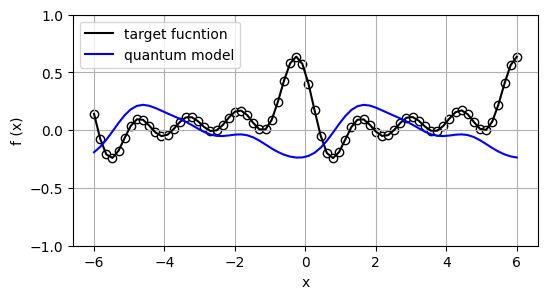

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_1)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.02913297528893146
Cost at step  10: 0.017874897670299886
Cost at step  15: 0.015978306183220194
Cost at step  20: 0.006705509309240555
Cost at step  25: 0.0068034591444273386
Cost at step  30: 0.004557302918143105
Cost at step  35: 0.003321670612177285
Cost at step  40: 0.0030643636789427888
Cost at step  45: 0.0016978890844142759
Cost at step  50: 0.0006507623193508684
Cost at step  55: 0.0008376871555408453
Cost at step  60: 0.00047926646826143977
Cost at step  65: 0.0001408610142851376
Cost at step  70: 0.0001915605042705615
Cost at step  75: 0.00014854548250821864
Cost at step  80: 8.057368712233019e-05
Cost at step  85: 8.124434284936482e-05
Cost at step  90: 1.7693959324387915e-05
Cost at step  95: 2.1456570786025194e-05
Cost at step 100: 2.699875985200298e-05
Cost at step 105: 1.1571398204474243e-05
Cost at step 110: 2.5038283602062217e-05
Cost at step 115: 4.979762240836865e-06
Cost at step 120: 2.945853503203257e-06
Cost at step 125: 2.0403607173084997e-06


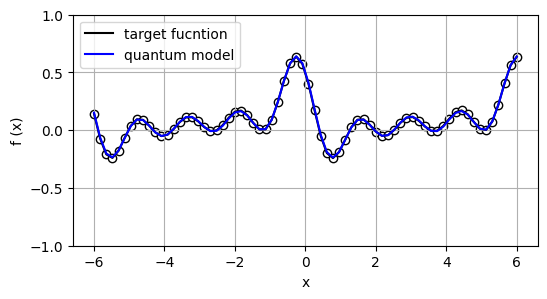

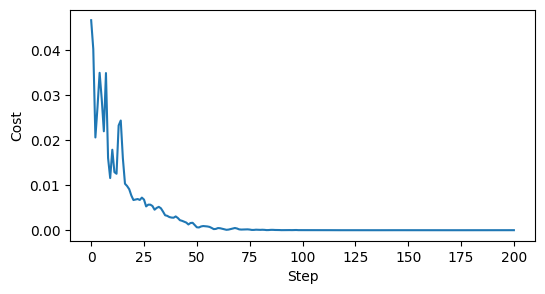

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Ansatz 2

In [ ]:
### setting ansatz ###

ansatz = 2
n_qubits = 2
n_layers = 4
dev = qml.device('default.qubit', wires=n_qubits)

def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)

def W_2(theta):
    """Trainable circuit block."""
    qcnn_unit9(theta[0],0,1)
    
@qml.qnode(dev)
def quantum_model_2(weights, x):

    for i in range(n_layers):
        W_2(weights[i])
        S(x)
    W_2(weights[n_layers])

    return qml.expval(qml.PauliZ(wires=0))

In [ ]:
### show ansatz circuit ###

weights = 2 * np.pi * np.random.random(size=(n_layers+1, 1, 15), requires_grad=True)

x_sample = -6
print(qml.draw(quantum_model_2, expansion_strategy="device")(weights,x_sample))

0: ──U3(2.76,2.22,3.77)─╭●──RY(4.27)─╭X──RY(4.68)─╭●──U3(3.81,4.67,0.34)──RX(-6.00)
1: ──U3(4.27,5.59,2.07)─╰X──RZ(5.71)─╰●───────────╰X──U3(1.09,2.25,5.79)──RX(-6.00)

───U3(1.46,0.11,0.78)─╭●──RY(1.27)─╭X──RY(0.86)─╭●──U3(3.41,1.32,4.68)──RX(-6.00)
───U3(6.26,2.88,5.42)─╰X──RZ(6.07)─╰●───────────╰X──U3(3.67,0.84,2.26)──RX(-6.00)

───U3(0.83,4.19,5.27)─╭●──RY(2.95)─╭X──RY(2.35)─╭●──U3(6.07,0.74,4.32)──RX(-6.00)
───U3(3.72,3.43,5.95)─╰X──RZ(0.95)─╰●───────────╰X──U3(6.10,2.17,3.87)──RX(-6.00)

───U3(2.97,1.99,2.93)─╭●──RY(1.37)─╭X──RY(1.20)─╭●──U3(2.41,1.96,1.63)──RX(-6.00)
───U3(0.84,5.38,3.93)─╰X──RZ(5.31)─╰●───────────╰X──U3(3.97,3.84,4.55)──RX(-6.00)

───U3(0.37,2.16,0.94)─╭●──RY(3.79)─╭X──RY(1.04)─╭●──U3(2.87,0.29,5.49)─┤  <Z>
───U3(2.87,5.08,4.61)─╰X──RZ(5.35)─╰●───────────╰X──U3(4.48,6.13,3.18)─┤     


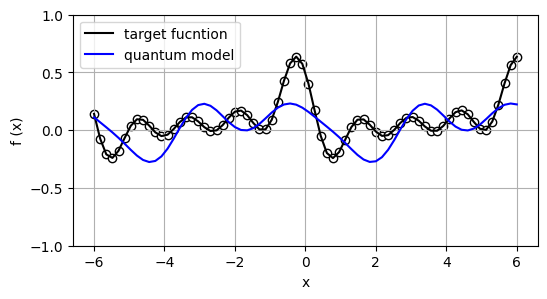

In [ ]:
### plot target function & quantum model with random weights ###

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, random_quantum_model_y, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

In [ ]:
### model training ###

def cost(weights, x, y):
    predictions = [1/(2**n_qubits)*np.real(np.trace(qml.matrix(quantum_model_2)(weights,x_))) for x_ in x]
    return square_loss(y, predictions)

max_steps = 200
opt = qml.AdamOptimizer(0.15)
batch_size = 25
cost_history = [cost(weights, x, target_y)]   
weights_history=[weights]  

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights = opt.step(lambda weights: cost(weights, x_batch, y_batch), weights)
    weights_history.append(weights)
 
    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cost_history.append(c)
    if (step + 1) % 5 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step   5: 0.027517391267139518
Cost at step  10: 0.022273474072731676
Cost at step  15: 0.0130553800798784
Cost at step  20: 0.009003397801432765
Cost at step  25: 0.009982331249847312
Cost at step  30: 0.005320692647009393
Cost at step  35: 0.004493605015830586
Cost at step  40: 0.002795732338778249
Cost at step  45: 0.0012149016551534532
Cost at step  50: 0.0009276850805390543
Cost at step  55: 0.000736233644580131
Cost at step  60: 0.0006149946226750698
Cost at step  65: 0.00013701285362599915
Cost at step  70: 0.00046272760638885695
Cost at step  75: 0.00028090766055545295
Cost at step  80: 0.0002754433237340154
Cost at step  85: 0.00010767338533584542
Cost at step  90: 0.00024182616586938707
Cost at step  95: 0.0001025177130679427
Cost at step 100: 0.00018009303487734362
Cost at step 105: 0.000158501685576089
Cost at step 110: 5.328755426952823e-05
Cost at step 115: 5.900221212201699e-05
Cost at step 120: 7.67477881126461e-05
Cost at step 125: 2.956647688669824e-05
Cost at

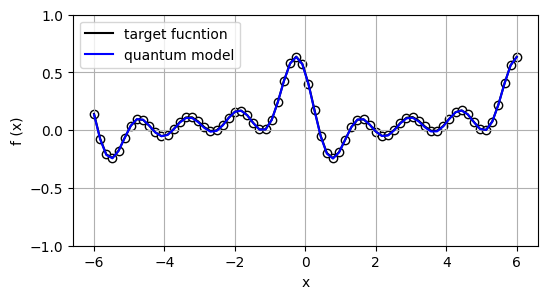

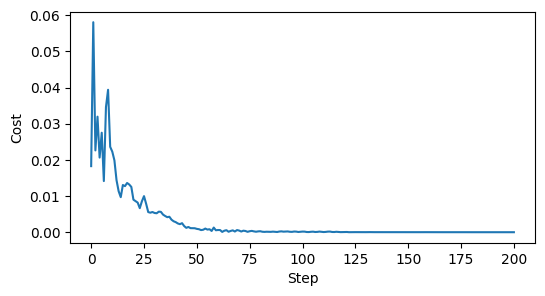

In [ ]:
### training results ###

predictions = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights,x_)))) for x_ in x]

plt.figure(figsize=(6,3))
plt.xlabel('x')
plt.ylabel('f (x)')
plt.yticks([-1,-0.5,0,0.5,1])
plt.plot(x, target_y, c='black',label='target fucntion')
plt.scatter(x, target_y, facecolor='white', edgecolor='black')
plt.plot(x, predictions, c='blue',label='quantum model')
plt.ylim(-1,1)
plt.legend()
plt.grid()
plt.show();

plt.figure(figsize=(6,3))
plt.plot(range(len(cost_history)), cost_history)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show();

In [ ]:
### save cost & weight history ###

np.save('./save/cost_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',cost_history)
np.save('./save/weight_hist_ansatz_'+str(ansatz)+'_degree_'+str(degree)+'_qubits_'+str(n_qubits)+'_layers_'+str(n_layers)+'.npy',weights_history)

### Final Plot

In [ ]:
### load weights ###

weights1=np.load('./save/weight_hist_ansatz_1_degree_4_qubits_2_layers_4.npy')[-1]
weights2=np.load('./save/weight_hist_ansatz_2_degree_4_qubits_2_layers_4.npy')[-1]

predictions1 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_1)(weights1,x_)))) for x_ in x]
predictions2 = [1/(2**n_qubits)*np.real(np.trace(np.array(qml.matrix(quantum_model_2)(weights2,x_)))) for x_ in x]

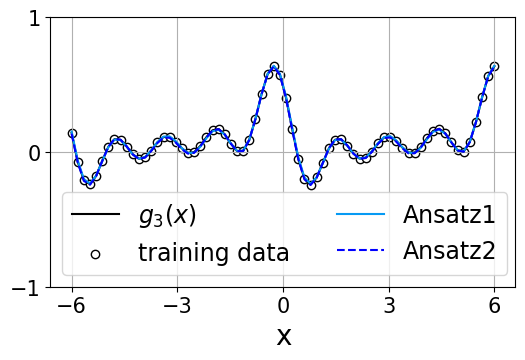

In [ ]:
### final plot ###

plt.figure(figsize=(6,3.5))
plt.xlabel('x',fontsize=20)
plt.yticks([-1,0,1],fontsize=15)
plt.xticks([-6,-3,0,3,6],fontsize=15)
plt.plot(x, target_y, c='black',label=r'$g_3(x)$')
plt.scatter(x, target_y, facecolor='white', edgecolor='black',label='training data')
plt.plot(x, predictions1, c='#069AF3',label='Ansatz1',alpha=1)
plt.plot(x, predictions2, c='#0000ff',label='Ansatz2',alpha=1,linestyle='--')
plt.ylim(-1,1)
plt.grid()
plt.legend(fontsize=17,ncols=2)
plt.show();